<a href="https://colab.research.google.com/github/bayhaqy/Pembelajaran_Mesin/blob/main/Pembelajaran_Mesin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pembelajaran Mesin**

## Pertemuan 2 - Mengambil Data dari Kaggle

In [ ]:
#Import Pandas dan Numpy
import numpy as np
import pandas as pd

In [ ]:
#Upload File Kaggle Json yang sudah di download sebelumnya

from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!ls -lhat loan-approval-classification-data

total 3.5M
-rw-r--r-- 1 root root 3.5M Oct  4 05:48 loan_data.csv
drwxr-xr-x 2 root root 4.0K Oct  4 05:48 .
drwxr-xr-x 1 root root 4.0K Oct  4 05:48 ..


In [ ]:
# Ubah permission file
!chmod 600 /content/kaggle.json

In [ ]:
# Setup Kaggle environment
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

In [ ]:
#!/bin/bash
!kaggle datasets download taweilo/loan-approval-classification-data

Dataset URL: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data
License(s): apache-2.0
  0% 0.00/751k [00:00<?, ?B/s]
100% 751k/751k [00:00<00:00, 1.01GB/s]


In [ ]:
# melakukan ekstraksi pada file zip
import zipfile
local_zip = '/content/loan-approval-classification-data.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/loan-approval-classification-data')
zip_ref.close()

In [ ]:
# Menghapus berkas zip yang sudah tidak diperlukan
!rm /content/loan-approval-classification-data.zip

In [ ]:
# show data top 10 using cat and head for data csv /content/loan-approval-classification-data/loan_data.csv
!cat /content/loan-approval-classification-data/loan_data.csv | head -n 10

person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.9,0.35,2.0,544,No,1


In [ ]:
df=pd.read_csv('/content/loan-approval-classification-data/loan_data.csv')

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
df.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [ ]:
print(df.dtypes)

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object


In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
df.describe(include="all")

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


## Pertemuan 3 - Data Cleaning dan Feature Selection

In [ ]:
#Import Library Python
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#df = pd.read_csv('/content/diabetes.csv')
df = pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Health/diabetes.csv')
df.shape

(768, 9)

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Data Cleaning

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### Feature Selection Menggunakan Pearson Correlation

Pearson correlation termasuk ke dalam jenis Filter Feature selection. Pearson correlation adalah metode yang paling sering digunakan untuk menghitung korelasi antar variabel. Dalam scikit-learn korelasi Pearson dilakukan dengan memanggil fungsi corr(). Hasilnya berupa matrik korelasi.

In [ ]:
corr_pearson = df.corr()

Untuk memudahkan membaca korelasi antar variabel yang dihasilkan, kita tampilkan matrik korelasi dalam grafik heatmap dengan menggunakan library Seaborn.

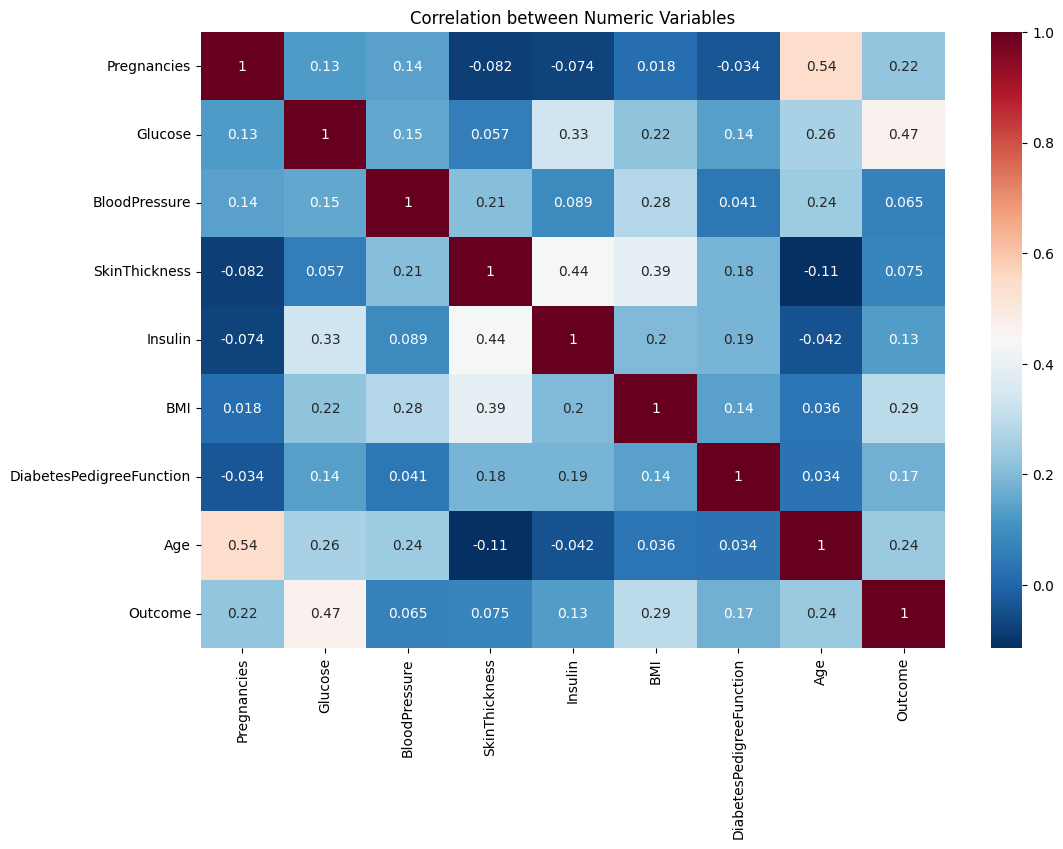

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_pearson, cmap="RdBu_r",annot=True)

plt.title('Correlation between Numeric Variables')
plt.show()

Pada baris paling bawah (nilai korelasi terhadap kolom Outcome), terlihat hampir semua kotak cenderung berwarna biru, yang berarti nilainya mendekati 0. Ini menandakan bahwa hampir semua fitur tidak memiliki hubungan signifikan dengan dengan kolom Outcome. Pada feature selection menggunakan perhitungan Pearson, hanya kolom Glucose yang dapat dipertimbangkan sebagai fitur yang memiliki hubungan dengan Outcome.

### Feature Selection Menggunakan Chi Square

Metode lain yang termasuk Filter Feature Selection adalah Chi Square. Pada bagian ini kita akan mencari 4 fitur yang memiliki nilai paling tinggi menggunakan perhitungan  Chi Square.

Sebelumnya kita akan memisahkan antara kolom fitur dan kolom target.

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df_feature = df.drop('Outcome',axis=1)
sr_outcome = df['Outcome']

df_feature.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
sr_outcome.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


Berikutnya, kita akan mencari 4 fitur yang memiliki nilai paling tinggi

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

chi2_selector = SelectKBest(chi2, k=4)
chi2_selector.fit(df_feature, sr_outcome)

cols = chi2_selector.get_support(indices=True)
df_selected_features = df_feature.iloc[:,cols]

df_selected_features merupakan fitur-fitur yang memiliki nilai tertinggi.

In [ ]:
df_selected_features.head()

,Glucose,Insulin,BMI,Age
0,148,0,33.6,50
1,85,0,26.6,31
2,183,0,23.3,32
3,89,94,28.1,21
4,137,168,43.1,33


Dari hasilnya maka terlihat 4 fitur yang dipilih adalah Glucose, Insulin, BMI dan Age

### Wrapper Feature Selection

Wrapper feature selection yang akan kita gunakan pada bagian ini adalah Recursive Feature Elimination atau RFE. Pada scikit-learn, RFE ada dalam modul sklearn.feature_selection

In [ ]:
from sklearn.feature_selection import RFE

Dalam wrapper feature selection kita harus mendefinisikan terlebih dahulu algoritma yang akan digunakan. Kali ini kita akan menggunakan random forest sebagai algoritma klasifikasi.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()

Kemudian kita implementasikan RFE dengan random forest untuk mencari 4 fitur terpenting, dengan menggunakan dataset yang kita gunakan sebelumnya.

In [ ]:
rfe = RFE(RandomForestClassifier(), n_features_to_select=4)
fit = rfe.fit(df_feature, sr_outcome)
print ("Hasil yang diperoleh adalah")
print("Num Features: %s" % (fit.n_features_))
print("Selected Features: %s" % (fit.support_))


Hasil yang diperoleh adalah
Num Features: 4
Selected Features: [False  True False False False  True  True  True]


In [ ]:
print("Hasilnya adalah fitur ke 1, 5, 6 dan 7.")

df_selected_features = df_feature.iloc[:,fit.support_]
df_selected_features.head()

Hasilnya adalah fitur ke 1, 5, 6 dan 7.


,Glucose,BMI,DiabetesPedigreeFunction,Age
0,148,33.6,0.627,50
1,85,26.6,0.351,31
2,183,23.3,0.672,32
3,89,28.1,0.167,21
4,137,43.1,2.288,33


Dari hasil di atas  terlihat 4 fitur yang dipilih adalah Glucose, BMI, DiabetesPedigreeFunction dan Age

### Embedded Feature Selection
Algoritma yang menggunakan konsep tree seperti random forest sebenarnya memiliki mekanisme untuk menentukan seberapa penting sebuah fitur. Pada random forest, nilai-nilai ini tersimpan dalam atribut feature_importances_

In [ ]:
print("Hasil yang ditampilkan oleh feature_importances_ adalah")

model_rf = RandomForestClassifier()
model_rf.fit(df_feature, sr_outcome)
model_rf.feature_importances_

Hasil yang ditampilkan oleh feature_importances_ adalah


array([0.08467667, 0.25180749, 0.09267707, 0.06778445, 0.07601909,
       0.16367041, 0.12463599, 0.13872881])

In [ ]:
df_feature.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


Dari hasilnya terlihat bahwa fitur yang dapat dianggap penting adalah Glucose, BMI, DiabetesPedigreeFunction dan Age.

Untuk algoritma klasifikasi linier seperti Linear SVM dan Logistic Regression, kita dapat menggunakan regularisasi L1 sebagai fungsi penalti untuk mengeliminasi fitur

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

model_lsvc = LinearSVC(C=0.01, penalty="l1", dual=False)
model_lsvc.fit(df_feature, sr_outcome)
sel_feature = SelectFromModel(model_lsvc, prefit=True)

Jika kita tampilkan fitur yang digunakan

In [ ]:
df_selected_features = df_feature.iloc[:,sel_feature.get_support()]
df_selected_features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age
0,6,148,72,35,0,33.6,50
1,1,85,66,29,0,26.6,31
2,8,183,64,0,0,23.3,32
3,1,89,66,23,94,28.1,21
4,0,137,40,35,168,43.1,33


Hasilnya terlihat bahwa ada satu field yang dibuang yaitu DiabetesPedigreeFunction

Embedded feature selection juga disebut sebagai automatic feature selection, karena pada awalnya semua fitur disertakan sebagai input, kemudian secara otomatis akan dieliminasi selama proses training.



## Pertemuan 4 - Algoritma Supervised Learning (Klasifikasi) : Naïve Bayes dan Decision Tree

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
for fn in uploaded.keys():
  print('User uploaded file "{name}"'.format(
      name=fn))

User uploaded file "kaggle.json"


In [ ]:
# Ubah permission file
!chmod 600 /content/kaggle.json

In [ ]:
# Setup Kaggle environment
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content"


In [ ]:
!kaggle datasets download oddyvirgantara/main-tenis

Dataset URL: https://www.kaggle.com/datasets/oddyvirgantara/main-tenis
License(s): unknown
  0% 0.00/607 [00:00<?, ?B/s]
100% 607/607 [00:00<00:00, 2.30MB/s]


In [ ]:
# melakukan ekstraksi pada file zip
import zipfile
local_zip = '/content/main-tenis.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/')
zip_ref.close()

In [ ]:
!ls /content/

kaggle.json	play_tennis_test.csv   sample_data
main-tenis.zip	play_tennis_train.csv


In [ ]:
import pandas as pd
df_test=pd.read_csv('/content/play_tennis_test.csv')
df_test

,day,outlook,temp,humidity,wind,play
0,D11,Sunny,Mild,Normal,Strong,Yes
1,D12,Overcast,Mild,High,Strong,Yes
2,D13,Overcast,Hot,Normal,Weak,Yes
3,D14,Rain,Mild,High,Strong,No


In [ ]:
import pandas as pd
df=pd.read_csv('/content/play_tennis_train.csv')

In [ ]:
df

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


### Persiapan Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   day       10 non-null     object
 1   outlook   10 non-null     object
 2   temp      10 non-null     object
 3   humidity  10 non-null     object
 4   wind      10 non-null     object
 5   play      10 non-null     object
dtypes: object(6)
memory usage: 612.0+ bytes


In [ ]:
df.isna().sum()

,0
day,0
outlook,0
temp,0
humidity,0
wind,0
play,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
data=df.drop('day', axis=1)

In [ ]:
data.head()

,outlook,temp,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi LabelEncoder
le = LabelEncoder()

# Kolom-kolom kategorikal yang akan diubah
categorical_cols = ['outlook', 'temp', 'humidity', 'wind']

# Melakukan label encoding untuk setiap kolom kategorikal
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Menampilkan data setelah label encoding
data.head()

,outlook,temp,humidity,wind,play
0,2,1,0,1,No
1,2,1,0,0,No
2,0,1,0,1,Yes
3,1,2,0,1,Yes
4,1,0,1,1,Yes


In [ ]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y)
X = data.drop('play', axis=1)
y = data['play']

# Bagi data menjadi training dan testing set (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # random_state untuk reproduktibilitas

# Menampilkan ukuran masing-masing set
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (7, 4)
Ukuran X_test: (3, 4)
Ukuran y_train: (7,)
Ukuran y_test: (3,)


In [ ]:
X_test

,outlook,temp,humidity,wind
8,2,0,1,1
1,2,1,0,0
5,1,0,1,0


### Naive Bayes

In [ ]:
from sklearn import naive_bayes
from sklearn import metrics

nb = naive_bayes.BernoulliNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

score = metrics.accuracy_score(y_test, y_pred)
print("Akurasi dengan menggunakan Naive Bayes: ", score)

Akurasi dengan menggunakan Naive Bayes:  0.6666666666666666


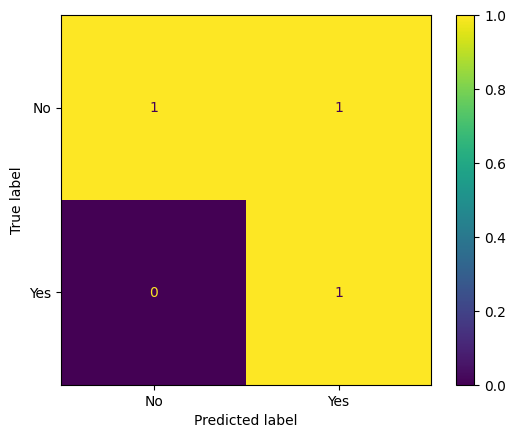

              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred, labels=nb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=nb.classes_)
disp.plot()
plt.show()



from sklearn.metrics import classification_report, confusion_matrix
print (classification_report(y_test, y_pred))




### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

# Inisialisasi Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=None, min_samples_split=2)

# Latih model dengan data training
dt_classifier.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_dt = dt_classifier.predict(X_test)

# Evaluasi akurasi model
score_dt = metrics.accuracy_score(y_test, y_pred_dt)
print("Akurasi dengan menggunakan Decision Tree: ", score_dt)

Akurasi dengan menggunakan Decision Tree:  0.3333333333333333


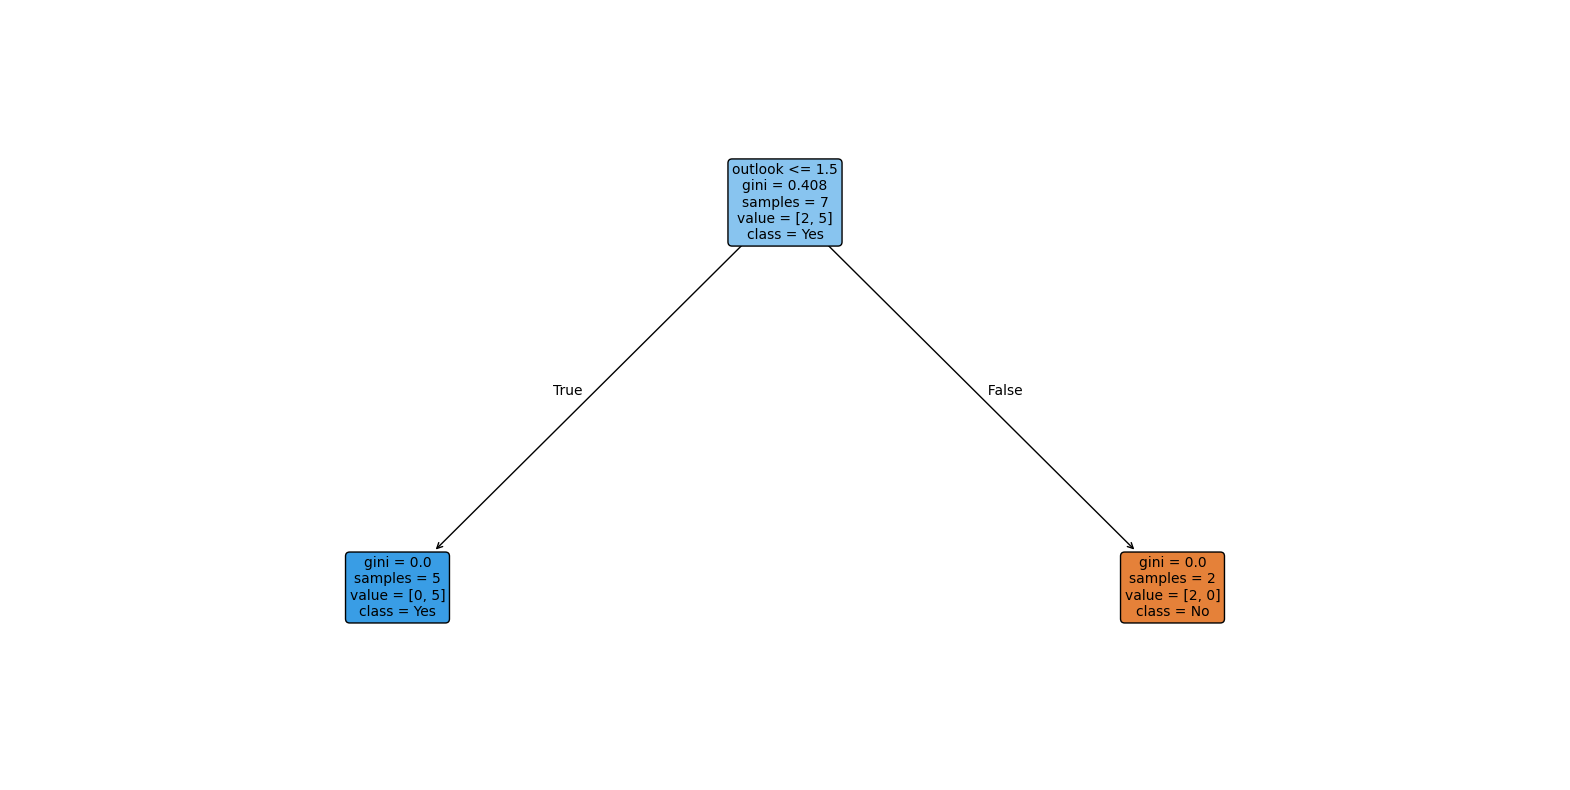

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Inisialisasi Decision Tree Classifier (gunakan parameter yang sama seperti sebelumnya)
dt_classifier = DecisionTreeClassifier(max_depth=4, min_samples_split=2)

# Latih model dengan data training
dt_classifier.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt_classifier,
          feature_names=X.columns,  # Nama fitur
          class_names=['No', 'Yes'],  # Nama kelas (sesuaikan dengan label Anda)
          filled=True, rounded=True, fontsize=10)
plt.show()

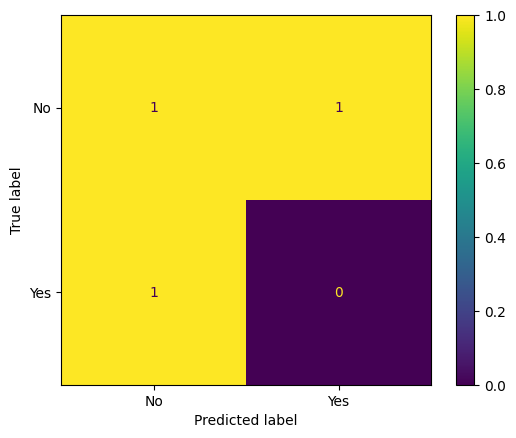

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred_dt, labels=dt_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dt_classifier.classes_)
disp.plot()
plt.show()



from sklearn.metrics import classification_report, confusion_matrix
print (classification_report(y_test, y_pred_dt))

### Logistic Regressor

Akurasi dengan menggunakan Logistic Regression:  0.6666666666666666


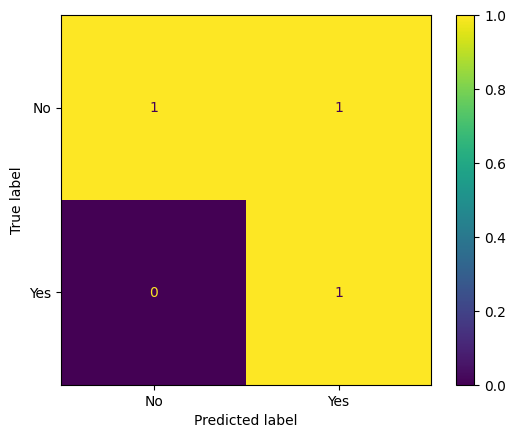

              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [ ]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi Logistic Regression Classifier
lr_classifier = LogisticRegression(random_state=42)

# Latih model dengan data training
lr_classifier.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_lr = lr_classifier.predict(X_test)

# Evaluasi akurasi model
score_lr = metrics.accuracy_score(y_test, y_pred_lr)
print("Akurasi dengan menggunakan Logistic Regression: ", score_lr)

cm = confusion_matrix(y_test, y_pred_lr, labels=lr_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lr_classifier.classes_)
disp.plot()
plt.show()

print (classification_report(y_test, y_pred_lr))

### SVM

Akurasi dengan menggunakan SVM:  0.3333333333333333


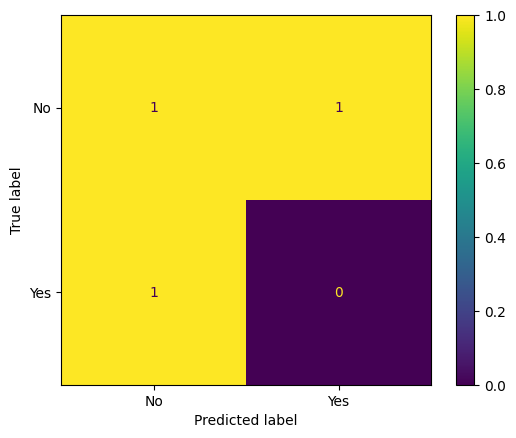

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [ ]:
from sklearn.svm import SVC

# Inisialisasi SVM Classifier
svm_classifier = SVC(kernel='linear') # Gunakan kernel linear sebagai contoh

# Latih model dengan data training
svm_classifier.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_svm = svm_classifier.predict(X_test)

# Evaluasi akurasi model
score_svm = metrics.accuracy_score(y_test, y_pred_svm)
print("Akurasi dengan menggunakan SVM: ", score_svm)

cm = confusion_matrix(y_test, y_pred_svm, labels=svm_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=svm_classifier.classes_)
disp.plot()
plt.show()

print (classification_report(y_test, y_pred_svm))

Akurasi dengan menggunakan SVM:  0.3333333333333333


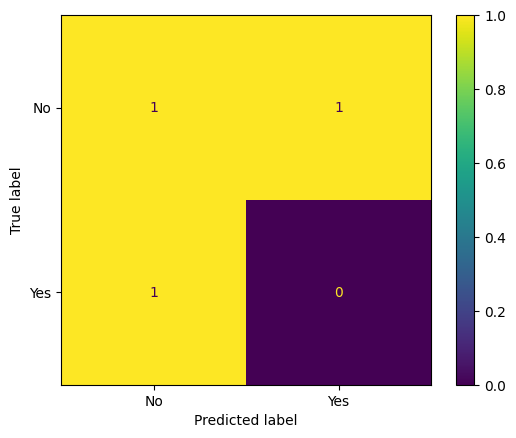

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [ ]:
from sklearn.svm import SVC

# Inisialisasi SVM Classifier
svm_classifierpoly = SVC(kernel='poly') # Gunakan kernel linear sebagai contoh

# Latih model dengan data training
svm_classifierpoly.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_svmpoly = svm_classifier.predict(X_test)

# Evaluasi akurasi model
score_svmpoly = metrics.accuracy_score(y_test, y_pred_svmpoly)
print("Akurasi dengan menggunakan SVM: ", score_svm)

cm = confusion_matrix(y_test, y_pred_svmpoly, labels=svm_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=svm_classifier.classes_)
disp.plot()
plt.show()

print (classification_report(y_test, y_pred_svmpoly))

Akurasi dengan menggunakan SVM:  0.3333333333333333


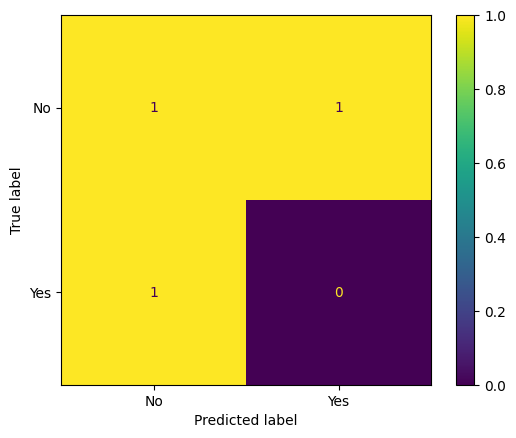

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [ ]:
from sklearn.svm import SVC

# Inisialisasi SVM Classifier
svm_classifierrbf = SVC(kernel='poly') # Gunakan kernel linear sebagai contoh

# Latih model dengan data training
svm_classifierrbf .fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_svmrbf = svm_classifier.predict(X_test)

# Evaluasi akurasi model
score_svmrbf = metrics.accuracy_score(y_test, y_pred_svmrbf)
print("Akurasi dengan menggunakan SVM: ", score_svm)

cm = confusion_matrix(y_test, y_pred_svmrbf, labels=svm_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=svm_classifier.classes_)
disp.plot()
plt.show()

print (classification_report(y_test, y_pred_svmrbf))

### KNN

Akurasi dengan menggunakan KNN:  0.6666666666666666


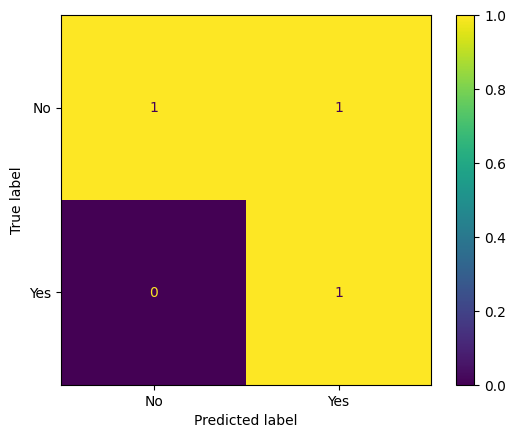

              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi KNN Classifier
knn_classifier = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')  # Gunakan 3 tetangga terdekat sebagai contoh

# Latih model dengan data training
knn_classifier.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_knn = knn_classifier.predict(X_test)

# Evaluasi akurasi model
score_knn = metrics.accuracy_score(y_test, y_pred_knn)
print("Akurasi dengan menggunakan KNN: ", score_knn)

cm = confusion_matrix(y_test, y_pred_knn, labels=knn_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_classifier.classes_)
disp.plot()
plt.show()

print(classification_report(y_test, y_pred_knn))

## Pertemuan 5 - Algoritma Supervised Learning: Logistic Regression, SVM dan k-NN


In [ ]:
from google.colab import files
uploaded=files.upload()

In [ ]:
for fn in uploaded.keys():
  print('User uploaded file "{name}"'.format(
      name=fn))

User uploaded file "kaggle.json"


In [ ]:
# Ubah permission file
!chmod 600 /content/kaggle.json

In [ ]:
# Setup Kaggle environment
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content"


In [ ]:
!kaggle datasets download oddyvirgantara/main-tenis

Dataset URL: https://www.kaggle.com/datasets/oddyvirgantara/main-tenis
License(s): unknown
  0% 0.00/607 [00:00<?, ?B/s]
100% 607/607 [00:00<00:00, 1.31MB/s]


In [ ]:
# melakukan ekstraksi pada file zip
import zipfile
local_zip = '/content/main-tenis.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/')
zip_ref.close()

In [ ]:
import pandas as pd
df=pd.read_csv('/content/play_tennis_train.csv')

In [ ]:
df.head()

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


### Persiapan Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   day       10 non-null     object
 1   outlook   10 non-null     object
 2   temp      10 non-null     object
 3   humidity  10 non-null     object
 4   wind      10 non-null     object
 5   play      10 non-null     object
dtypes: object(6)
memory usage: 608.0+ bytes


In [ ]:
df.isna().sum()

,0
day,0
outlook,0
temp,0
humidity,0
wind,0
play,0


In [ ]:
df.duplicated().sum()

0

In [ ]:
data=df.drop('day', axis=1)

In [ ]:
data.head()

,outlook,temp,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi LabelEncoder
le = LabelEncoder()

# Kolom-kolom kategorikal yang akan diubah
categorical_cols = ['outlook', 'temp', 'humidity', 'wind']

# Melakukan label encoding untuk setiap kolom kategorikal
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Menampilkan data setelah label encoding
data.head()

,outlook,temp,humidity,wind,play
0,2,1,0,1,No
1,2,1,0,0,No
2,0,1,0,1,Yes
3,1,2,0,1,Yes
4,1,0,1,1,Yes


In [ ]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y)
X = data.drop('play', axis=1)
y = data['play']

# Bagi data menjadi training dan testing set (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # random_state untuk reproduktibilitas

# Menampilkan ukuran masing-masing set
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (7, 4)
Ukuran X_test: (3, 4)
Ukuran y_train: (7,)
Ukuran y_test: (3,)


### Naive Bayes

In [ ]:
from sklearn import naive_bayes
from sklearn import metrics

nb = naive_bayes.BernoulliNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

score = metrics.accuracy_score(y_test, y_pred)
print("Akurasi dengan menggunakan Naive Bayes: ", score)

Akurasi dengan menggunakan Naive Bayes:  0.6666666666666666


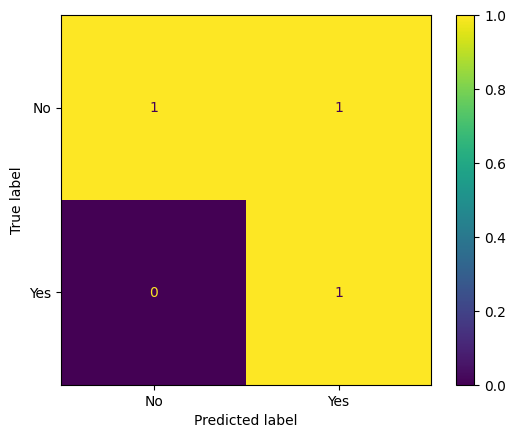

              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred, labels=nb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=nb.classes_)
disp.plot()
plt.show()



from sklearn.metrics import classification_report, confusion_matrix
print (classification_report(y_test, y_pred))




### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

# Inisialisasi Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=None, min_samples_split=2)

# Latih model dengan data training
dt_classifier.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_dt = dt_classifier.predict(X_test)

# Evaluasi akurasi model
score_dt = metrics.accuracy_score(y_test, y_pred_dt)
print("Akurasi dengan menggunakan Decision Tree: ", score_dt)

Akurasi dengan menggunakan Decision Tree:  0.3333333333333333


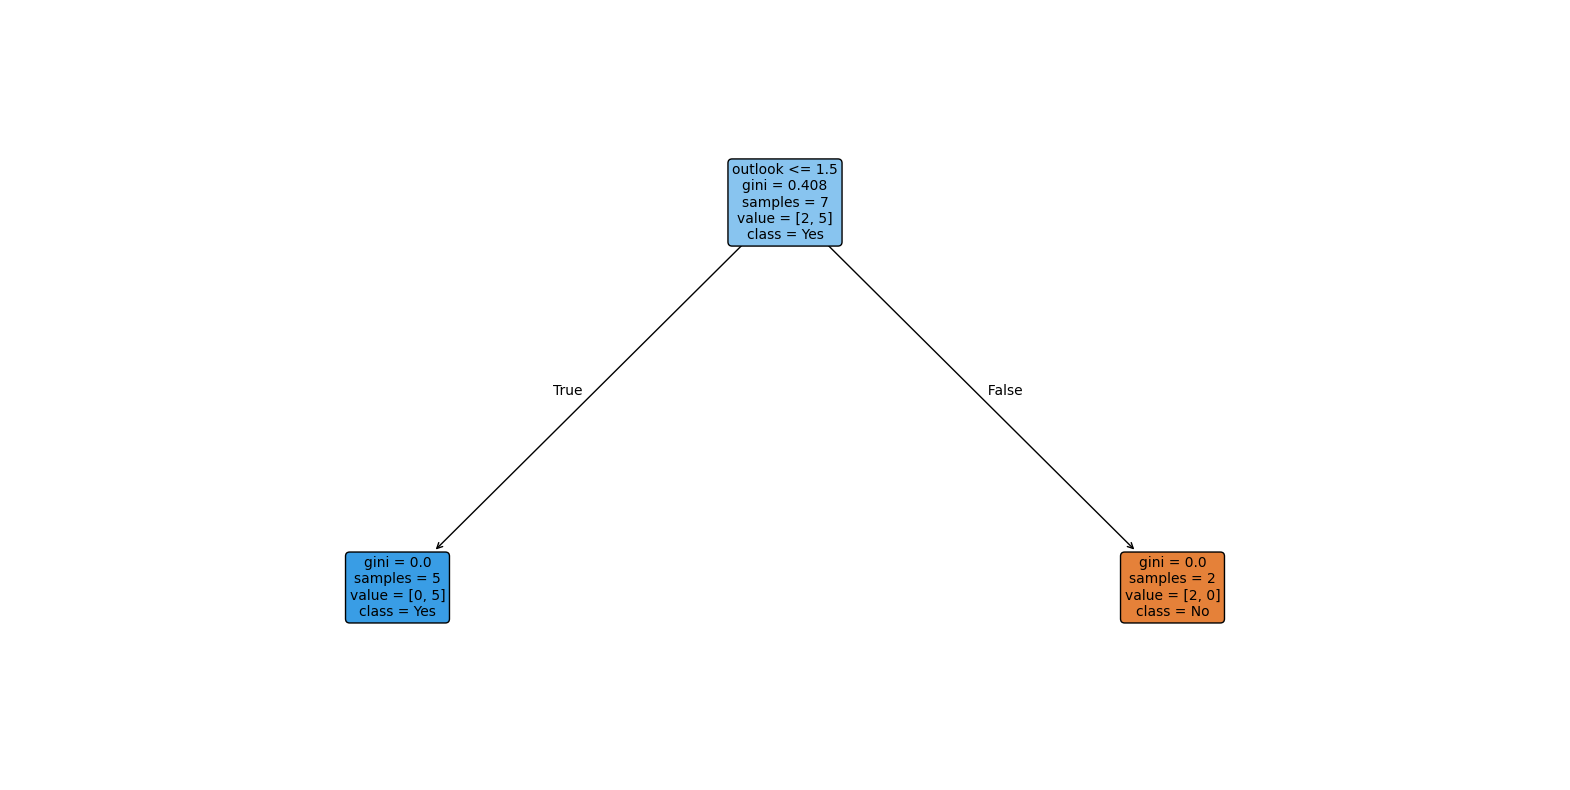

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Inisialisasi Decision Tree Classifier (gunakan parameter yang sama seperti sebelumnya)
dt_classifier = DecisionTreeClassifier(max_depth=4, min_samples_split=2)

# Latih model dengan data training
dt_classifier.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt_classifier,
          feature_names=X.columns,  # Nama fitur
          class_names=['No', 'Yes'],  # Nama kelas (sesuaikan dengan label Anda)
          filled=True, rounded=True, fontsize=10)
plt.show()

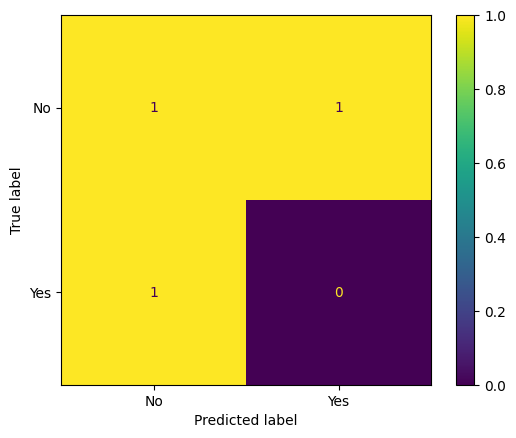

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred_dt, labels=dt_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dt_classifier.classes_)
disp.plot()
plt.show()



from sklearn.metrics import classification_report, confusion_matrix
print (classification_report(y_test, y_pred_dt))

### Logistic Regressor

Akurasi dengan menggunakan Logistic Regression:  0.6666666666666666


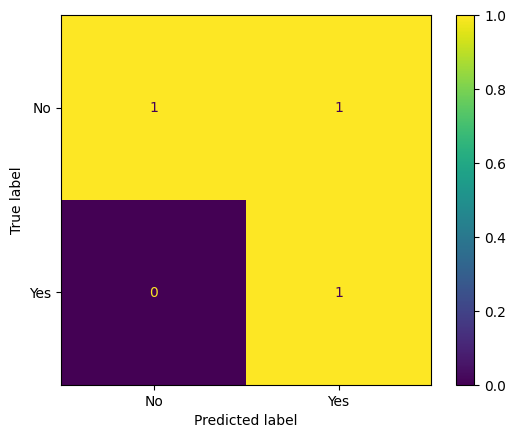

              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [ ]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi Logistic Regression Classifier
lr_classifier = LogisticRegression(random_state=42)

# Latih model dengan data training
lr_classifier.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_lr = lr_classifier.predict(X_test)

# Evaluasi akurasi model
score_lr = metrics.accuracy_score(y_test, y_pred_lr)
print("Akurasi dengan menggunakan Logistic Regression: ", score_lr)

cm = confusion_matrix(y_test, y_pred_lr, labels=lr_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lr_classifier.classes_)
disp.plot()
plt.show()

print (classification_report(y_test, y_pred_lr))

### SVM

Akurasi dengan menggunakan SVM:  0.3333333333333333


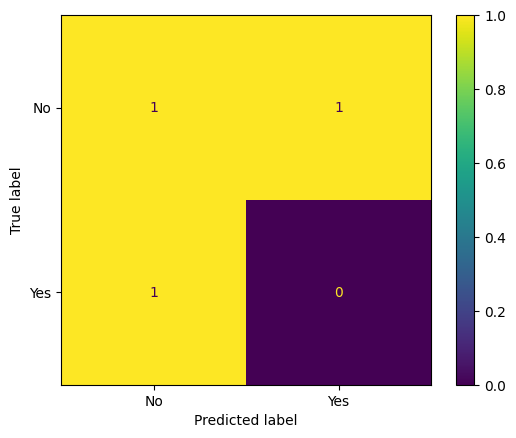

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [ ]:
from sklearn.svm import SVC

# Inisialisasi SVM Classifier
svm_classifier = SVC(kernel='linear') # Gunakan kernel linear sebagai contoh

# Latih model dengan data training
svm_classifier.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_svm = svm_classifier.predict(X_test)

# Evaluasi akurasi model
score_svm = metrics.accuracy_score(y_test, y_pred_svm)
print("Akurasi dengan menggunakan SVM: ", score_svm)

cm = confusion_matrix(y_test, y_pred_svm, labels=svm_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=svm_classifier.classes_)
disp.plot()
plt.show()

print (classification_report(y_test, y_pred_svm))

Akurasi dengan menggunakan SVM:  0.3333333333333333


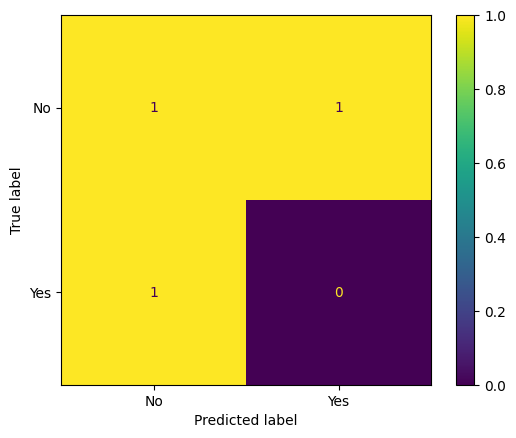

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [ ]:
from sklearn.svm import SVC

# Inisialisasi SVM Classifier
svm_classifierpoly = SVC(kernel='poly') # Gunakan kernel linear sebagai contoh

# Latih model dengan data training
svm_classifierpoly.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_svmpoly = svm_classifier.predict(X_test)

# Evaluasi akurasi model
score_svmpoly = metrics.accuracy_score(y_test, y_pred_svmpoly)
print("Akurasi dengan menggunakan SVM: ", score_svm)

cm = confusion_matrix(y_test, y_pred_svmpoly, labels=svm_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=svm_classifier.classes_)
disp.plot()
plt.show()

print (classification_report(y_test, y_pred_svmpoly))

Akurasi dengan menggunakan SVM:  0.3333333333333333


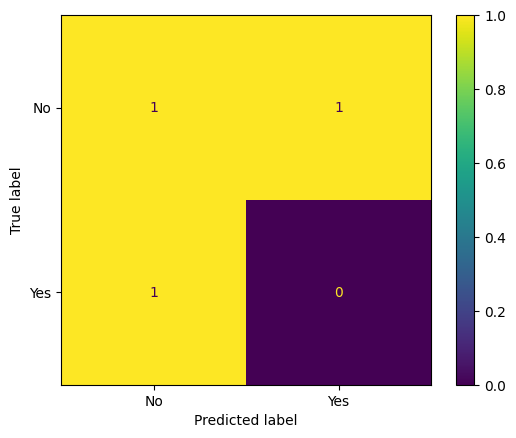

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [ ]:
from sklearn.svm import SVC

# Inisialisasi SVM Classifier
svm_classifierrbf = SVC(kernel='poly') # Gunakan kernel linear sebagai contoh

# Latih model dengan data training
svm_classifierrbf .fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_svmrbf = svm_classifier.predict(X_test)

# Evaluasi akurasi model
score_svmrbf = metrics.accuracy_score(y_test, y_pred_svmrbf)
print("Akurasi dengan menggunakan SVM: ", score_svm)

cm = confusion_matrix(y_test, y_pred_svmrbf, labels=svm_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=svm_classifier.classes_)
disp.plot()
plt.show()

print (classification_report(y_test, y_pred_svmrbf))

### KNN

Akurasi dengan menggunakan KNN:  0.6666666666666666


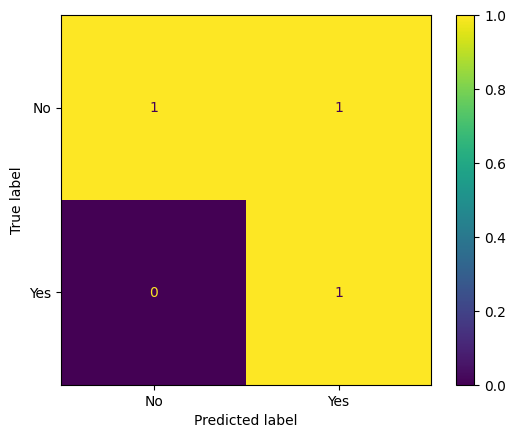

              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi KNN Classifier
knn_classifier = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')  # Gunakan 3 tetangga terdekat sebagai contoh

# Latih model dengan data training
knn_classifier.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_knn = knn_classifier.predict(X_test)

# Evaluasi akurasi model
score_knn = metrics.accuracy_score(y_test, y_pred_knn)
print("Akurasi dengan menggunakan KNN: ", score_knn)

cm = confusion_matrix(y_test, y_pred_knn, labels=knn_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_classifier.classes_)
disp.plot()
plt.show()

print(classification_report(y_test, y_pred_knn))

## Pertemuan 6 - Algoritma Supervised Learning (Regresi)

### SIMPLE LINEAR REGRESSION

Pada notebook kali ini, kita akan mempelajari tentang simple linear regression. Linear Regression atau Regresi Linier adalah salah satu metode supervised learning dalam machine learning. Berbeda dengan metode klasifikasi yang memprediksi kelas atau kategori sebuah item, regresi linier berfungsi untuk memprediksi sebuah nilai berdasarkan atribut yang tersedia. Yang diprediksi adalah sejauh mana hubungan sebab akibat antara Variabel Faktor Penyebab (x) terhadap variabel akibat (y).

Apabila variabel bebasnya hanya satu, maka analisis regresinya menggunakan regresi linier sederhana. Apabila variabel bebasnya lebih dari satu, maka analisis regresinya menggunakan regresi linier berganda.

#### Contoh penggunaan analisis regresi linier sederhana antara lain:

* Hubungan antara jumlah pekerja dengan jumlah produksi
* Hubungan antara lama waktu bekerja dengan jabatan yang dimiliki saat ini
* Hubungan antara lama waktu PDKT dengan keberhasilan mendapat jodoh


![alt text](https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Linear_regression.svg/1200px-Linear_regression.svg.png)


Secara sederhana regresi linier adalah teknik untuk memprediksi sebuah nilai dari variable Y (variabel dependen) berdasarkan beberapa variabel tertentu X (variabel independen) jika terdapat hubungan linier antara X dan Y. Untuk teori lengkap mengenai regresi linier sederhana, dapat dilihat artikel tulisan ole **R. Kukuh** di medium pada [tautan berikut ini](https://medium.com/machine-learning-id/simple-linear-regression-teori-d4abebd1ade2)

Dapat kita lihat juga bahwa garis regresi yang kita buat tidak tepat mengenai semua titik-titik variabelnya. Jarak dari garis regresi ke titik-titik variabel ini lah yang akan menjadi nilai error dari permodelan regresi kita

![alt text](https://community.cloudera.com/t5/image/serverpage/image-id/25068iFF075A5AEC3B8528/image-size/medium?v=1.0&px=400)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt #untuk plotting
from sklearn.linear_model import LinearRegression #import library LinearRegression dari scikit-learn


In [ ]:
#Buat Data Frame Sendiri
a=['nama','kamera', 'price']
phone=['H1','H2','H3','H4','H5','H6','H7','H8']
kamera=[8,2,6,9,4,5,7,3]
harga=[7,3,7,None,2,None,8,3]

#Buat Data Dictionary
D={a[0]:phone, a[1]:kamera,a[2]:harga}

# Import data dictionary to pandas dataframe
df=pd.DataFrame(data=D)

df


,nama,kamera,price
0,H1,8,7.0
1,H2,2,3.0
2,H3,6,7.0
3,H4,9,NaN
4,H5,4,2.0
5,H6,5,NaN
6,H7,7,8.0
7,H8,3,3.0


Dan selanjutnya kita akan mencari Σy, (Σx²), Σx dan Σxy. Rumusnya dapat dilihat pada artikel/tutorial sebelumnya.

In [ ]:
# Find Σy
sigmaY = sum(filter(lambda y: isinstance(y,int),harga))

# Find (Σx²), Σx and Σxy
sigmaXsquare = 0
sigmaX = 0
sigmaXY = 0
dataLength = 0

for index, val in enumerate(kamera):
  if isinstance(harga[index],int):
    sigmaXsquare += val**2
    sigmaX += val
    sigmaXY += val*harga[index]
    dataLength +=1

sumsigmaXsquare = sigmaX**2

Menggunakan variable tersebut selanjutnya kita akan menghitung nilai konstanta a.

In [ ]:
Konstanta_a = ((sigmaY*sigmaXsquare)-(sigmaX*sigmaXY))/((dataLength*sigmaXsquare)-sumsigmaXsquare)
round(Konstanta_a,3)

0.179

Lalu kita cari koefisien b dengan cara berikut ini.

In [ ]:
# Find coefficient b
koefesien_b = ((dataLength*sigmaXY)-(sigmaX*sigmaY))/((dataLength*sigmaXsquare)-sumsigmaXsquare)
round(koefesien_b,3)

0.964

Kemudian kita lakukan prediksi terhadap data harga handphone H4 dan H6 menggunakan code berikut ini.

In [ ]:
# Find missing price H4 and H6
# y = a+bx
for index,val in enumerate(harga):
  if not isinstance(val,int):
   harga[index] = round(Konstanta_a+(koefesien_b*kamera[index]),2)

Lalu hasil perhitungan beserta data yang ada kita visualisasikan menggunakan seaborn dan matplotlib.

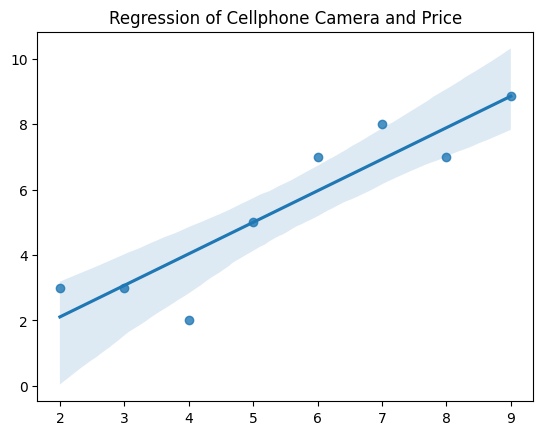

In [ ]:
# creater linear graph

import seaborn as sns

sns.regplot(x = kamera, y = harga, data=df)
plt.title('Regression of Cellphone Camera and Price')
plt.show()

#### Membuat Data Sendiri

In [ ]:
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None)

LinearRegression()

In [ ]:
#buat data

penjualan = np.array([6,5,5,4,4,3,2,2,2,1])
harga = np.array([16000, 18000, 27000, 34000, 50000, 68000, 65000, 81000, 85000, 90000])





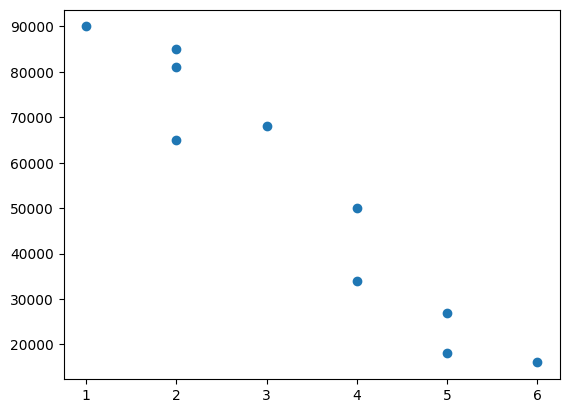

In [ ]:
#buat plot
plt.scatter (penjualan, harga)

In [ ]:
#buat permodelan regresi

penjualan= penjualan.reshape (-1,1) #kita tukar baris dan kolom variabel ini, agar bisa dikalikan dalam operasi matriks
#untuk lebih lengkapnya baca teori soal perhitungan regresi linier

linreg = LinearRegression()
linreg.fit(penjualan, harga)

LinearRegression()

In [ ]:
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None)


LinearRegression()

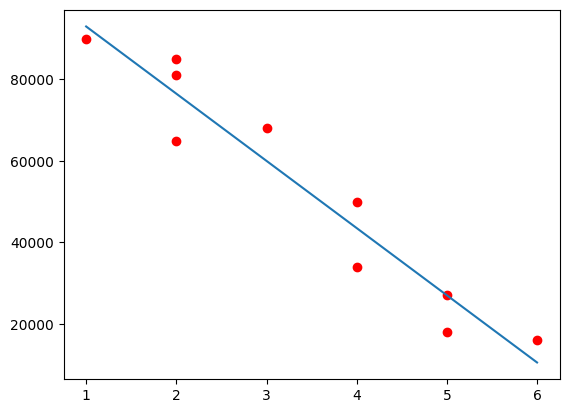

In [ ]:
#plot hasil regresi

plt.scatter(penjualan, harga, color='red')
plt.plot(penjualan, linreg.predict(penjualan))

Kita dapat melihat hubungan antara kedua variabel yang kita buat. Dalam hal ini saya membuat hubungan antara jumlah penjualan dengan harga barang. Dapat dilihat, semakin murah harga barang, maka jumlah penjualan naik.

#### Dengan Dataset

Kita akan belajar cara menggunakan library scikit-learn pada python untuk membuat permodelan regresi linier sederhana. Data yang akan kita gunakan adalah dataset konsumsi bahan bakar pada mobil yang kita dapat dari IBM Object Storage

In [ ]:
#import library dan package yang dibutuhkan

import pandas as pd #untuk dataframe
import pylab as pl #untuk plotting

In [ ]:
#download data

!wget -O FuelConsumption.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv

--2025-12-13 05:33:48--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumption.csv’

FuelConsumption.csv 100%[===================>]  70.93K  --.-KB/s    in 0.02s   

2025-12-13 05:33:49 (3.58 MB/s) - ‘FuelConsumption.csv’ saved [72629/72629]



In [ ]:
df = pd.read_csv("FuelConsumption.csv") #membaca data

# melihat 5 baris pertama data
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [ ]:
#kita ambil kolom mana saja yang akan kita analisis, dan membuang sisanya

cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,CO2EMISSIONS
0,2.0,4,9.9,196
1,2.4,4,11.2,221
2,1.5,4,6.0,136
3,3.5,6,12.7,255
4,3.5,6,12.1,244
5,3.5,6,11.9,230
6,3.5,6,11.8,232
7,3.7,6,12.8,255
8,3.7,6,13.4,267


Sebagai contoh, kita lihat hubungan antara variabel konsumsi bahan bakar di kota dengan emisi CO2

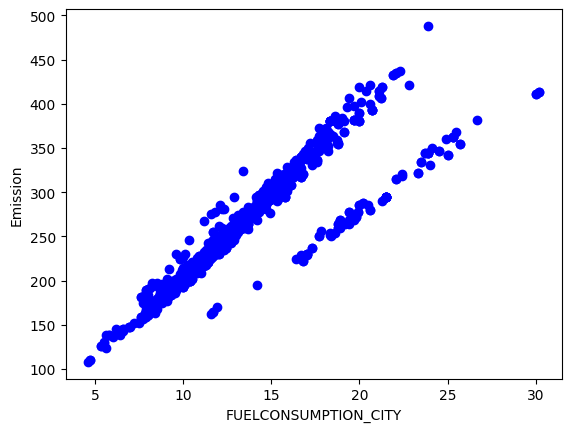

In [ ]:
plt.scatter(cdf.FUELCONSUMPTION_CITY, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_CITY")
plt.ylabel("Emission")
plt.show()

Sebagai contoh juga, kita lihat hubungan antara variabel ukuran mesin dengan emisi CO2

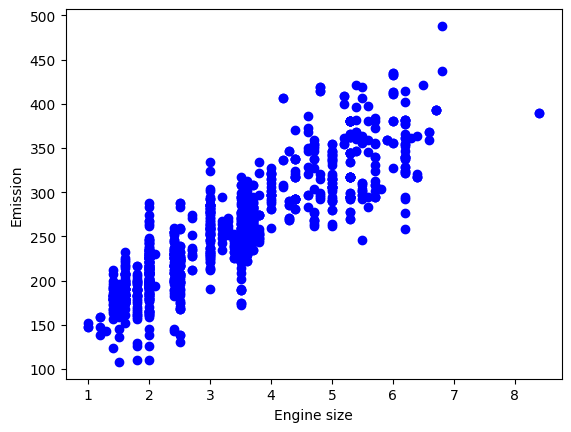

In [ ]:
#Kita plot hubungannya

plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

#### Melakukan Data Splitting

Dalam membuat permodelan Machine Learning, merupakan suatu hal yang lazim untuk membagi data ke dalam data latih (train) dan data uji (test). Kita gunakan data latih untuk melatih model, dan data uji untuk menilai performa dari permodelan yang kita buat. Hal ini kita lakukan untuk mensimulasikan, apakah model kita dapat bekerja dengan baik dalam menganalisa kasus yang belum pernah ia temui sebelumnya

![alt text](https://miro.medium.com/max/936/0*VH8IKfRP4mewrsTo.png)

Biasanya data latih akan berjumlah sekitar 70-80% dari semua data, dan sisanya adalah data latih.

In [ ]:
#Membagi data

msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

print (train)
print (test)

      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_CITY  CO2EMISSIONS
0            2.0          4                   9.9           196
1            2.4          4                  11.2           221
3            3.5          6                  12.7           255
4            3.5          6                  12.1           244
5            3.5          6                  11.9           230
...          ...        ...                   ...           ...
1060         3.0          6                  13.2           264
1062         3.0          6                  13.4           271
1064         3.0          6                  13.4           271
1065         3.2          6                  12.9           260
1066         3.2          6                  14.9           294

[863 rows x 4 columns]
      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_CITY  CO2EMISSIONS
2            1.5          4                   6.0           136
7            3.7          6                  12.8           255
8            3.7

Cari hubungan antara ukuran mesin dengan emisi CO2 pada kendaraan

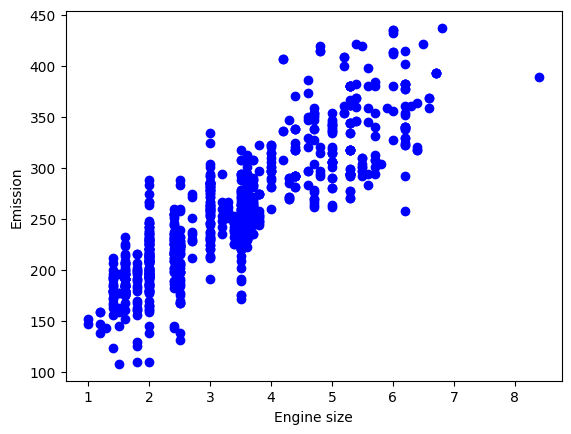

In [ ]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

#### Membuat Model Regresi

In [ ]:
#Membuat model regresi


regr = LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)

# Koefisien model
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [[38.82901917]]
Intercept:  [126.23685529]


Dalam membuat model regresi, sebenarnya kita mencari nilai-nilai Coefficient (gradien/kemiringan) dan Intercept yang kita sebut parameter model. Untuk memahami hal ini, disarankan untuk mempelajari persamaan garis dan teori dasar regresi linier pada tautan yang sudah diberikan.

Text(0, 0.5, 'Emission')

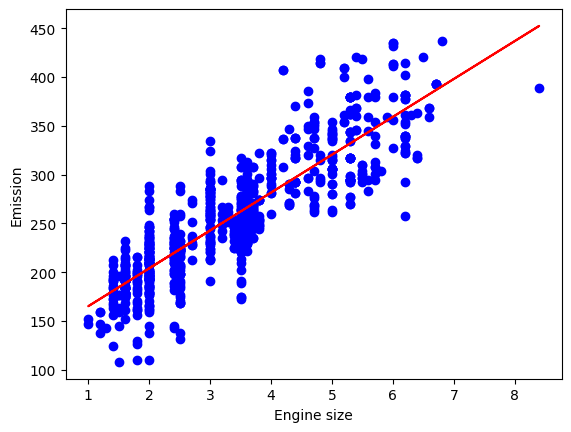

In [ ]:
#Plot hasil regresi

plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [ ]:
#Menghitung error

from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 22.82
Residual sum of squares (MSE): 948.03
R2-score: 0.73


Dapat kita lihat, bahwa error yang dihasilkan model regresi yang kita buat cukup besar. Hal ini dikarenakan masih banyak faktor lain yang memengaruhi emisi CO2 pada kasus di atas. Permodelan regresi linier sederhan masih tergolong metode machine learning yang masih dasar. Oleh karena itu, kita perlu menggunakan metode machine learning yang lebih powerful lagi.

#### Linear Regresi Sederhana - Nilai Siswa

In [ ]:
import pandas as pd
df=pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Education/Student_Marks.csv')
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


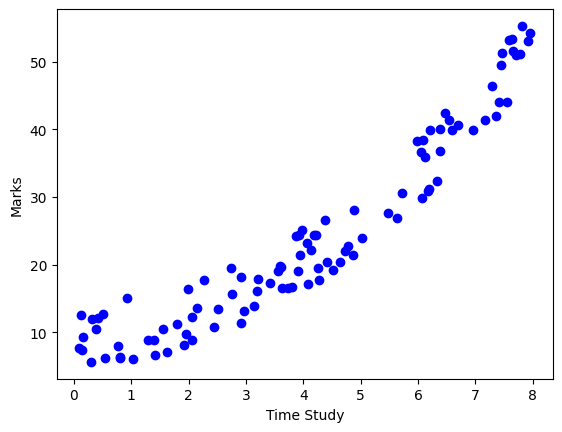

In [ ]:
#Kita plot hubungannya
import matplotlib.pyplot as plt #untuk plotting

plt.scatter(df.time_study, df.Marks,  color='blue')
plt.xlabel("Time Study")
plt.ylabel("Marks")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
train, test=train_test_split(df, test_size=0.2, random_state=42)

#dataset train dan test diurutkan untuk tujuan ploting


train=train.sort_values(by='time_study')
test=test.sort_values(by='time_study')

X_train,X_test=train[['time_study']],test[['time_study']]
y_train,y_test=train[['Marks']],test[['Marks']]


print (X_train.shape,X_test.shape)
print (y_train.shape,y_test.shape)

(80, 1) (20, 1)
(80, 1) (20, 1)


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


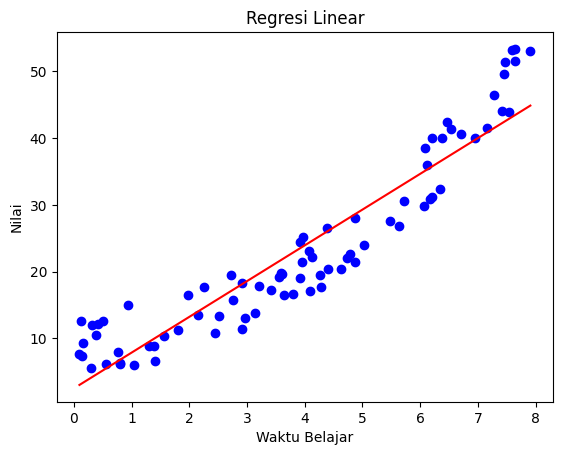

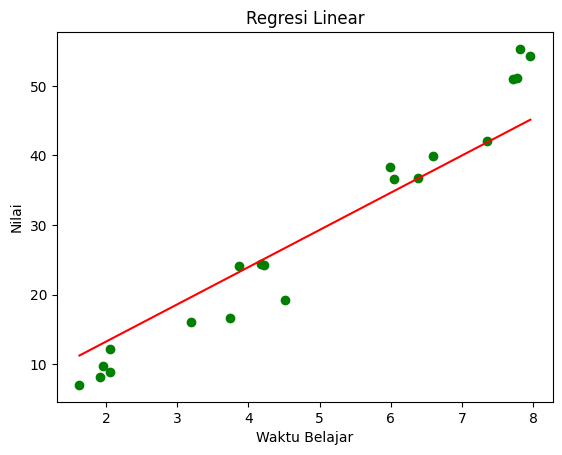

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train, color = "blue")
plt.plot(X_train, model.predict(X_train), color = "red")
plt.title("Regresi Linear")
plt.xlabel("Waktu Belajar")
plt.ylabel("Nilai")
plt.show()

plt.scatter(X_test, y_test, color = "green")
plt.plot(X_test, model.predict(X_test), color = "red")
plt.title("Regresi Linear")
plt.xlabel("Waktu Belajar")
plt.ylabel("Nilai")
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 25.236745623632178
R-squared: 0.9040228286990539


### <center>Regresi Linear - Variabel Jamak </center>


####Tentang Notebook
Dalam notebook ini, akan dipelajari cara menggunakan scikit-learn untuk mengimplementasikan regresi linier variabel jamak. Data yang dipakai adalah kumpulan data yang terkait dengan, ukuran mesin, silinder, konsumsi bahan bakar dengan emisi karbon dioksida mobil. Kemudian, data dibagi menjadi data pelatihan dan data pengujian, kemudian pembuatan model menggunakan dataset pelatihan, evaluasi model menggunakan dataset pengujian, dan akhirnya penggunaan model untuk memprediksi nilai yang tidak diketahui


#### Import packages yang diperlukan

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np


#### Pengunduhan Data
Untuk mengunduh data, gunakan !wget dengan URL yang diberikan.

In [ ]:
!wget -O FuelConsumption.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv

--2025-12-13 05:38:37--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumption.csv’

FuelConsumption.csv 100%[===================>]  70.93K  --.-KB/s    in 0.02s   

2025-12-13 05:38:37 (2.79 MB/s) - ‘FuelConsumption.csv’ saved [72629/72629]



#### Memahami Data

####`FuelConsumption.csv`:
Dataset **`FuelConsumption.csv`** yang diunduh mengandung model spesifik untuk rating konsumsi bahan bakar (fuel consumption) dan estimasi emisi karbon dioksida untuk kendaraan ringan yang dijual di Kanada.
[Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

- **MODELYEAR** e.g. 2014
- **MAKE** e.g. Acura
- **MODEL** e.g. ILX
- **VEHICLE CLASS** e.g. SUV
- **ENGINE SIZE** e.g. 4.7
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. A6
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 9.9
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 8.9
- **FUEL CONSUMPTION COMB (L/100 km)** e.g. 9.2
- **CO2 EMISSIONS (g/km)** e.g. 182   --> low --> 0


#### Membaca Data

In [ ]:
df = pd.read_csv("FuelConsumption.csv")

# melihat dataset
df.head()



,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


#### Eksplorasi Data
Eksplorasi deskriptif data yang diunduh.

In [ ]:
# merangkum data
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Beberapa fitur dapat dieksplorasi dengan cara berikut.

In [ ]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(10)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267
9,2.4,4,9.2,212


Fitur-fitur tersebut dapat diplot sebagai berikut:

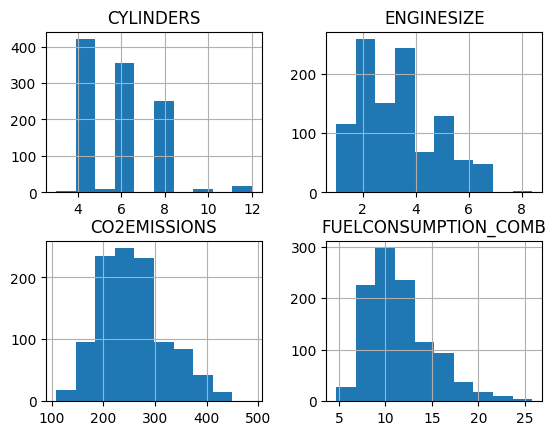

In [ ]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()

Plot fitur-fitur vs emisi dapat dibuat dan dapat dilihat linearitas hubungannya.

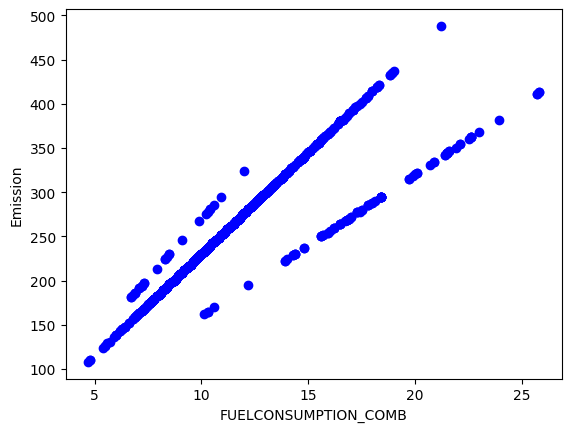

In [ ]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

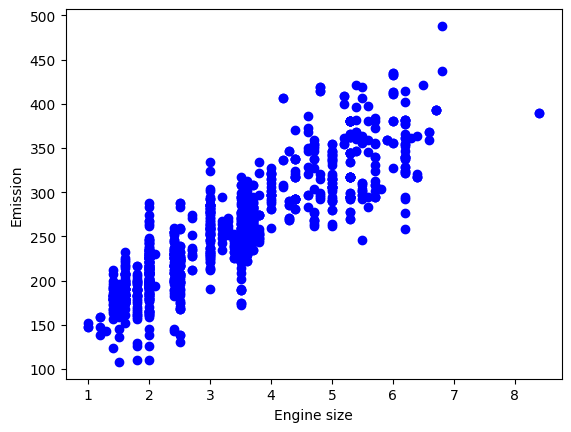

In [ ]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

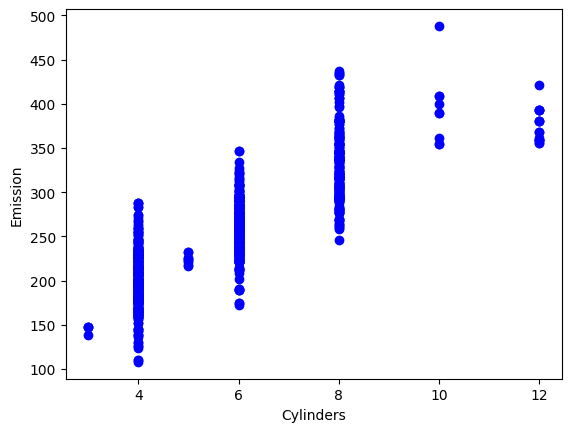

In [ ]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()

##### Pembuatan dataset pelatihan dan pengujian
Pemisahan data latih/uji melibatkan pemisahan dataset menjadi dataset pelatihan dan pengujian, yang saling eksklusif. Setelah itu, dataset pelatihan dapat digunakan untuk membuat model dan dataset pengujian untuk pengujian.
Hal ini akan memberikan evaluasi yang lebih akurat pada akurasi out-of-sample karena dataset pengujian bukan merupakan bagian dari dataset yang telah digunakan untuk melatih data. Ini lebih realistis untuk masalah dunia nyata.

Ini berarti bahwa hasil dari setiap titik data dalam kumpulan data ini diketahui, sehingga sangat bagus untuk data pengujian. Dataset pengujian belum digunakan untuk melatih model, sehingga model tidak memiliki pengetahuan tentang hasil dari data ini, sehingga dapat disebut pengujian di luar sampel.



In [ ]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

#### Model Regresi Variabel Jamak
Regresi Linier cocok dengan model linier dengan koefisien B = (B1, ..., Bn) untuk meminimalkan 'jumlah kuadrat sisa (residu)' antara x bebas (X1, ..., Xn) dalam kumpulan data, dan y tak bebas dengan pendekatan linier.

##### Distribusi Data Pelatihan

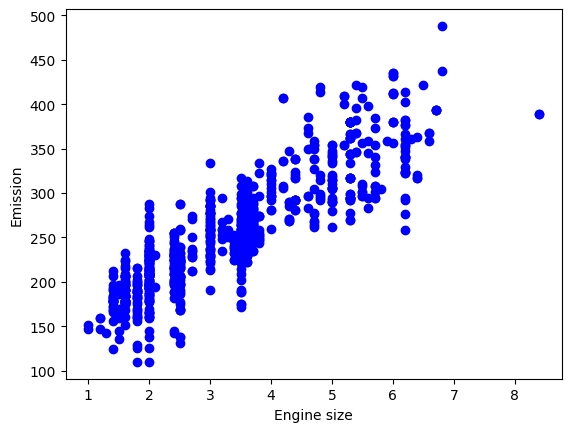

In [ ]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

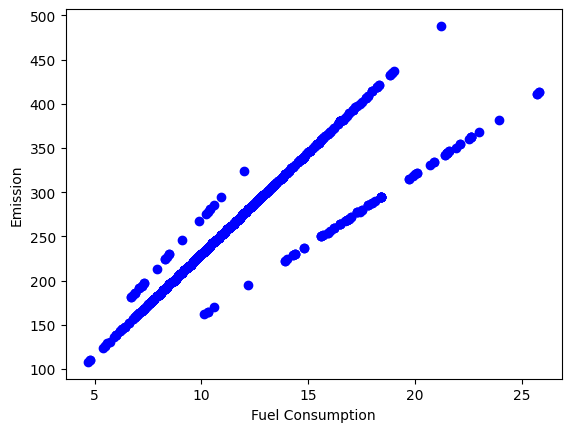

In [ ]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Fuel Consumption")
plt.ylabel("Emission")
plt.show()

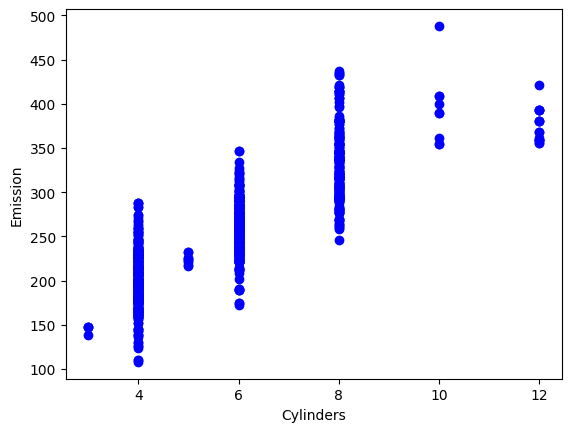

In [ ]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()

In [ ]:
# prompt: buat data träning dan testing untuk cdf

from sklearn.model_selection import train_test_split

# Assuming 'cdf' is your dataframe as defined in the original code
X = cdf[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = cdf['CO2EMISSIONS']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% training, 20% testing

# Now you have X_train, X_test, y_train, y_test for your model
print("Training data shape:", X_train.shape, y_train.shape)
print("Testing data shape:", X_test.shape, y_test.shape)

Training data shape: (853, 3) (853,)
Testing data shape: (214, 3) (214,)


In [ ]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)


# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [11.2094395   7.15561381  9.5208118 ]
Intercept:  67.3483851836209


Text(0.5, 1.0, 'Residual Plots')

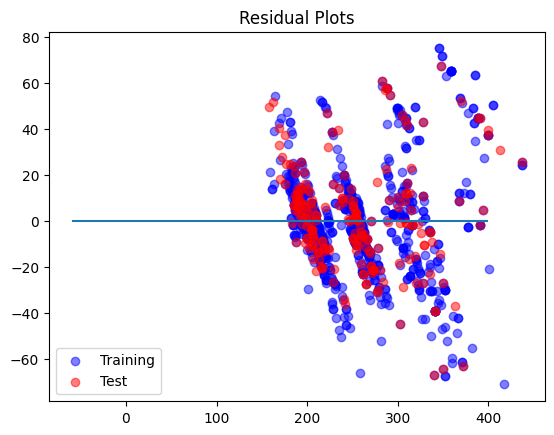

In [ ]:
y_train_pred = regr.predict(X_train)
y_test_pred = regr.predict(X_test)

# Scatter plot the training data
train = plt.scatter(y_train_pred,(y_train_pred-y_train),c='b',alpha=0.5)

# Scatter plot the testing data
test = plt.scatter(y_test_pred ,(y_test_pred-y_test ),c='r',alpha=0.5)

# Plot a horizontal axis line at 0
plt.hlines(y=0,xmin=-60,xmax=400)
plt.legend((train,test),('Training','Test'),loc='lower left')
plt.title('Residual Plots')

Berdasarkan residual plot tersebut, dapat dilihat mayoritas titik-titik residu untuk training set dan test set tersebar secara acak di sekitar sumbu horizontal. Berdasarkan hal tersebut, maka dapat disimpulkan bahwa model regresi linear sesuai untuk data yang dianalisis.

In [ ]:
from sklearn.metrics import r2_score

# Make predictions using the testing set
y_pred = regr.predict(X_test)

# Evaluate the model using R-squared
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

# You can also use other metrics like Mean Absolute Error (MAE) or Mean Squared Error (MSE)
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

R-squared: 0.875970520691407
Mean Absolute Error: 16.721593983516485
Mean Squared Error: 512.8551370148301
Root Mean Squared Error: 22.64630515149944


#### Penjelasan Hasil di Atas

## R-squared:
R-squared adalah koefisien determinasi yang menunjukkan seberapa baik model dapat menjelaskan variabilitas data target. Nilai R-squared berada dalam rentang 0 hingga 1, di mana:
*   0 berarti model sama sekali tidak mampu menjelaskan variansi data.
*   1 berarti model menjelaskan seluruh variansi data dengan sempurna.

Dengan nilai R² sebesar 0.8759, artinya model mampu menjelaskan 87,59% dari variansi data target. Ini menunjukkan bahwa model memiliki performa yang sangat baik dalam memprediksi data.




## Mean Absolute Error (MAE):
MAE adalah rata-rata dari selisih absolut antara nilai sebenarnya dan nilai prediksi.

Dengan nilai MAE sebesar 16.72, rata-rata kesalahan prediksi model adalah 16.72 unit dari nilai sebenarnya.


## Mean Squared Error (MSE):
MSE adalah rata-rata dari kuadrat selisih antara nilai sebenarnya dan nilai prediksi.

Nilai MSE memberikan bobot lebih besar untuk kesalahan yang lebih besar karena selisihnya dikuadratkan. Dengan nilai MSE sebesar 512.86, rata-rata kesalahan model dikuadratkan adalah sekitar 512.86 unit persegi.


## Root Mean Squared Error (RMSE):
RMSE adalah akar kuadrat dari MSE

RMSE memberikan nilai kesalahan dalam satuan yang sama dengan data asli, sehingga lebih mudah diinterpretasikan dibanding MSE. Dengan nilai RMSE sebesar 22.65, rata-rata kesalahan prediksi model adalah sekitar 22.65 unit.


#Kesimpulan:

*     R-squared yang tinggi (0.8759) menunjukkan model cukup akurat dalam
menjelaskan variansi data.
*     MAE dan RMSE menunjukkan tingkat kesalahan rata-rata model dalam satuan asli data, dengan MAE lebih kecil dari RMSE, yang normal karena RMSE menghukum kesalahan besar lebih berat.
*   MSE berguna untuk menganalisis besarnya kesalahan kuadrat rata-rata.



# Kesimpulannya, model memiliki performa yang cukup baik, meskipun masih ada ruang untuk pengoptimalan lebih lanjut jika diperlukan.










### LassoRegressor_Prediksi_Nilai_Siswa

#### Import Pandas dan Memanggil data

Saya menggunakan kumpulan data nilai siswa dari kaggle . Data tersebut terdiri dari nilai siswa, waktu belajar, dan jumlah mata kuliah yang diambil.

In [ ]:
import pandas as pd
df=pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Education/Student_Marks.csv')
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


Untuk masalah regresi univariat , kita memilih time_study sebagai fiturnya. Kita harus memprediksi nilai siswa berdasarkan rata-rata waktu belajar siswa per hari.

In [ ]:
from sklearn.model_selection import train_test_split
train, test=train_test_split(df, test_size=0.2, random_state=42)

#dataset train dan test diurutkan untuk tujuan ploting


train=train.sort_values(by='time_study')
test=test.sort_values(by='time_study')

X_train,X_test=train[['time_study']],test[['time_study']]
y_train,y_test=train[['Marks']],test[['Marks']]

In [ ]:
from sklearn.preprocessing import StandardScaler

### Saat menggunakan StandardScaler(), metode fit() mengharapkan input seperti array 2D
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import Lasso


# Inisialisasi dan latih model Lasso
lasso_model = Lasso(alpha=1.0)  # Anda dapat menyesuaikan nilai alpha
lasso_model.fit(X_train_scaled, y_train)

# Prediksi pada data uji
y_pred = lasso_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 34.231998040366264
R-squared (R2): 0.8698132323045137


Hasil evaluasi model Lasso Regression yang Anda sebutkan memiliki dua metrik utama:



*  Mean Squared Error (MSE):
Nilainya adalah 34.231998040366264, menunjukkan rata-rata kuadrat kesalahan prediksi model terhadap nilai sebenarnya. Semakin kecil nilai MSE, semakin baik kinerja model. Dalam konteks ini, nilai tersebut harus dibandingkan dengan variabilitas data untuk menilai apakah model sudah cukup baik.
*   R-squared (R²):
Nilainya adalah 0.8698132323045137. R² menunjukkan proporsi variasi dalam data target (
y
) yang dapat dijelaskan oleh fitur (X) dalam model. Nilai mendekati 1 menunjukkan model yang sangat baik dalam menjelaskan variasi data. Dengan R² sekitar 0.87, model Anda memiliki kinerja yang sangat baik, yang berarti sekitar 87% variasi data target dijelaskan oleh fitur.


#### Interpretasi Hasil
*   Kombinasi MSE yang cukup rendah dan R² yang tinggi menunjukkan bahwa model Lasso Regression bekerja dengan baik untuk dataset Anda.

### RandomForest_Regressor

##### Proses

**import pandas as pd**
*   Mengimpor pustaka Pandas dengan alias pd untuk manipulasi dan analisis data.
*  Pandas digunakan untuk bekerja dengan data dalam format tabel seperti DataFrame.

**df=pd.read_csv('/content/Student_Marks.csv')**
*  Membaca file CSV bernama Student_Marks.csv yang berlokasi di /content/ (umumnya lokasi penyimpanan pada Google Colab).
*   Hasil pembacaan ini disimpan ke dalam variabel df sebagai DataFrame, yang merupakan struktur data 2D (mirip tabel) dalam Pandas.
*   DataFrame menyimpan data dalam format kolom (attributes) dan baris (records).

**df.head()**
*  Menampilkan 5 baris pertama dari DataFrame secara default.
*  Digunakan untuk melihat sekilas struktur data, termasuk kolom, tipe data, dan sampel data.
*   Anda juga bisa menentukan jumlah baris yang ingin ditampilkan, misalnya df.head(10) untuk 10 baris pertama.

In [ ]:
import pandas as pd
df=pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Education/Student_Marks.csv')
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [ ]:
#Menampilkan Info dari Data Frame seperti Dtype dari data frame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


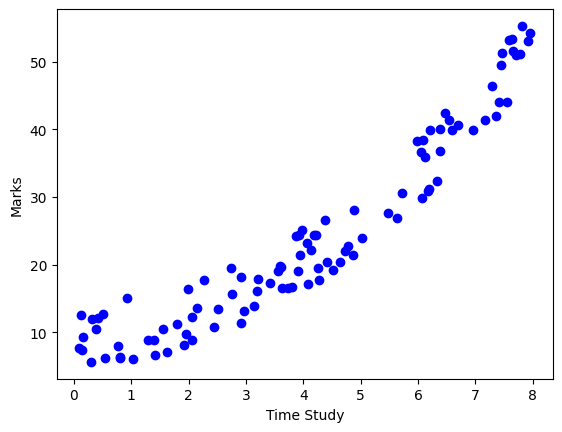

In [ ]:
#Kita plot hubungannya antra Time_Study dan Marks

import matplotlib.pyplot as plt #untuk plotting

plt.scatter(df.time_study, df.Marks,  color='blue')
plt.xlabel("Time Study")
plt.ylabel("Marks")
plt.show()

In [ ]:

#dataset train dan test diurutkan untuk tujuan ploting

from sklearn.model_selection import train_test_split
train, test=train_test_split(df, test_size=0.2, random_state=42)



train=train.sort_values(by='time_study')
test=test.sort_values(by='time_study')

X_train,X_test=train[['time_study']],test[['time_study']]
y_train,y_test=train[['Marks']],test[['Marks']]


print (X_train.shape,X_test.shape)
print (y_train.shape,y_test.shape)

(80, 1) (20, 1)
(80, 1) (20, 1)


In [ ]:
# Fitting Random Forest Regression to the dataset

from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 100, random_state=0) # (n_estimators = 100 Jumlah pohon dalam hutan (misalnya, 200 atau 300).

regressor.fit(X_train,y_train)
y_pred=regressor.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


##### Penjelasan
*  n_estimators=100: Menentukan jumlah pohon dalam hutan.
Default adalah 100, tetapi bisa ditingkatkan untuk performa yang lebih baik (contoh: 200 atau 300).
*   random_state=0: Menetapkan nilai seed untuk memastikan hasil eksekusi konsisten setiap kali dijalankan.





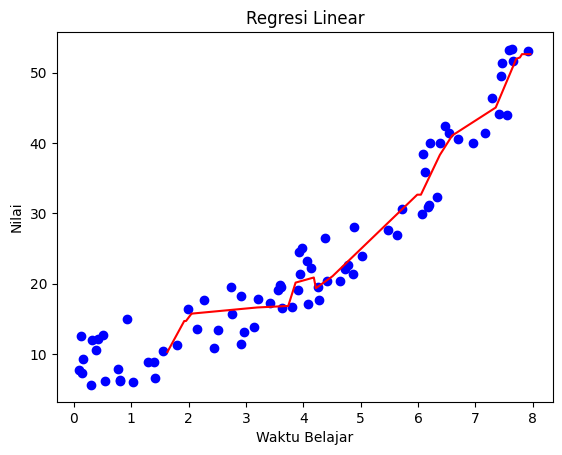

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train, color = "blue", label="Data Asli")


plt.plot(X_test, regressor.predict(X_test), color = "red", label="Prediksi")
plt.title("Regresi Linear")
plt.xlabel("Waktu Belajar")
plt.ylabel("Nilai")
plt.show()



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 13.349657391085032
R-squared: 0.9492302861335136


Hasil evaluasi model menunjukkan bahwa Random Forest Regressor berhasil memberikan performa yang sangat baik dalam memprediksi target berdasarkan dataset yang diberikan. Berikut interpretasi dari metrik yang dihitung:


**Mean Squared Error (MSE): 13.35**
MSE mengukur rata-rata kesalahan kuadrat antara nilai sebenarnya (y_test) dan nilai prediksi (y_pred).
*   Nilai lebih kecil lebih baik: Dalam konteks ini, nilai 13.35 menunjukkan bahwa kesalahan prediksi model cukup kecil dibandingkan dengan varians target.

**R-squared (R²): 0.95**
R² mengukur seberapa baik model menjelaskan variansi dalam data target (y). Nilai R² berkisar antara:
*   1.0: Model sempurna, semua variansi target dijelaskan oleh fitur.
*   0.0: Model tidak menjelaskan variansi target sama sekali.
Negatif: Model lebih buruk dibandingkan dengan rata-rata sederhana.
R² = 0.95 menunjukkan bahwa model menjelaskan 95% variansi dalam data target, yang merupakan performa sangat baik.




### SVR - Prediksi Nilai Siswa

##### Import Pandas dan Memanggil data


Saya menggunakan kumpulan data nilai siswa dari kaggle . Data tersebut terdiri dari nilai siswa, waktu belajar, dan jumlah mata kuliah yang diambil.

In [ ]:
import pandas as pd
df=pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Education/Student_Marks.csv')
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


Untuk masalah regresi univariat , kita memilih time_study sebagai fiturnya. Kita harus memprediksi nilai siswa berdasarkan rata-rata waktu belajar siswa per hari.

In [ ]:
from sklearn.model_selection import train_test_split
train, test=train_test_split(df, test_size=0.2, random_state=42)

#dataset train dan test diurutkan untuk tujuan ploting


train=train.sort_values(by='time_study')
test=test.sort_values(by='time_study')

X_train,X_test=train[['time_study']],test[['time_study']]
y_train,y_test=train[['Marks']],test[['Marks']]

Skala fitur
Karena SVR adalah algoritma berbasis jarak, penskalaan merupakan langkah praproses penting yang dapat meningkatkan akurasi dan stabilitas model.



In [ ]:
from sklearn.preprocessing import StandardScaler

### Saat menggunakan StandardScaler(), metode fit() mengharapkan input seperti array 2D
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Pemasangan model SVR
Modul sklearn.svm menyertakan berbagai kelas SVR.



*   svm.SVR adalah kelas yang  mengimplementasikan SVR. Hiperparameternya adalah fungsi kernel , C , dan ε.
*   svm.LinSVR mirip dengan kelas SVR dengan parameter kernel='linear' tetapi memiliki kinerja yang lebih baik untuk kumpulan data yang besar. Hiperparameternya adalah C dan ε.

*   svm.NuSVR menggunakan parameter nu yang mengontrol jumlah vektor pendukung dan kompleksitas model. Mirip dengan kelas SVR , hiperparameternya adalah fungsi kernel , C , dan ε.









In [ ]:
# Fitting SVR to the dataset
from sklearn.svm import SVR
regressor_lin = SVR(kernel = 'linear')
regressor_rbf= SVR(kernel = 'rbf')
regressor_poli= SVR(kernel = 'poly')

#linear = Linear Kernel
regressor_lin.fit(X_train_scaled , y_train)
regressor_rbf.fit(X_train_scaled , y_train)
regressor_poli.fit(X_train_scaled , y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(kernel='poly')

##### Mengevaluasi kinerja model

Visualisasi merupakan metode yang berharga untuk mengevaluasi kinerja suatu model. Oleh karena itu, saya memplot garis yang paling sesuai di atas titik data aktual untuk set data pelatihan guna memberikan representasi yang jelas tentang kinerja model.

Text(0, 0.5, 'Mark')

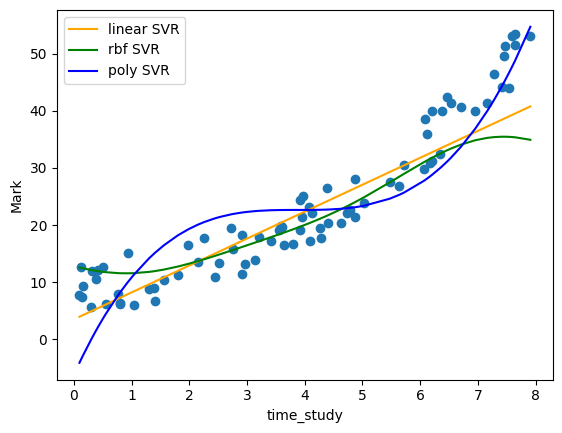

In [ ]:
from matplotlib import pyplot as plt

#### Prediksi model untuk kumpulan data kereta ####
train[ 'linear_svr_pred' ] = regressor_lin.predict(X_train_scaled)
train[ 'rbf_svr_pred' ] = regressor_rbf.predict(X_train_scaled)
train[ 'poly_svr_pred' ] = regressor_poli.predict(X_train_scaled)


#### Visualisasi ####
plt.scatter(train[ 'time_study' ], train[ 'Marks' ])
plt.plot(train[ 'time_study' ], train[ 'linear_svr_pred' ], color = 'orange' , label = 'linear SVR' )
plt.plot(train[ 'time_study' ], train[ 'rbf_svr_pred' ], color = 'green' , label = 'rbf SVR' )
plt.plot(train[ 'time_study' ], train[ 'poly_svr_pred' ], color = 'blue' , label = 'poly SVR' )
plt.legend()
plt.xlabel( 'time_study' )
plt.ylabel( 'Mark' )



Seperti yang disebutkan sebelumnya, SVR memiliki hiperparameter yang dapat disetel; ε , C, dan Kernel. Dengan menyetel hiperparameter ini, kita dapat memperoleh kecocokan model yang lebih baik dengan set data pelatihan.

Di bawah ini, saya mengevaluasi kinerja model SVR linear pada kumpulan data uji menggunakan dua metrik, skor R-kuadrat (R2) dan kesalahan akar rata-rata kuadrat (RMSE) beserta plot nilai target aktual vs. nilai target yang diprediksi.

In [ ]:
import numpy as np
from sklearn import metrics
from sklearn.metrics import r2_score

#### Uji set data - metrik ####
y_test_pred = regressor_lin.predict(X_test_scaled)
r2_score = round(metrics.r2_score(y_test, y_test_pred), 2 )
rmse = round(np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)), 2 )
print( f'r2: {r2_score} ' )
print( f'rmse: {rmse} ' )


r2: 0.83 
rmse: 6.7 


Nilai R2 sebesar 0,83 menunjukkan bahwa sekitar 83% varians nilai siswa dapat dijelaskan oleh rata-rata waktu belajar. Nilai RMSE sebesar 6,7 menunjukkan besarnya rata-rata residual (kesalahan prediksi) antara nilai siswa aktual dan prediksi.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


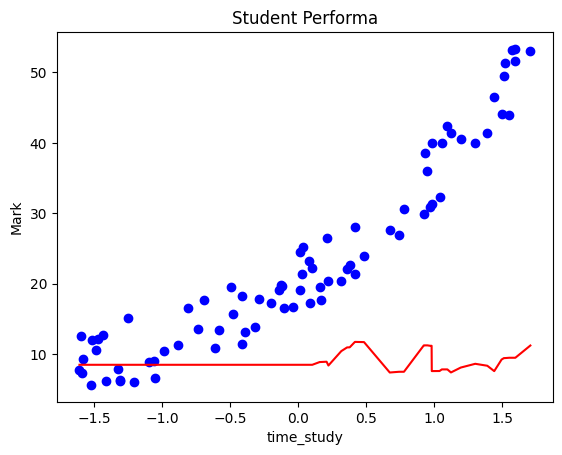

In [ ]:
# Visualising the SVR results
plt.scatter(X_train_scaled, y_train, color = 'blue')
plt.plot(X_train_scaled, regressor.predict(X_train_scaled), color = 'red')
plt.title('Student Performa')
plt.xlabel( 'time_study' )
plt.ylabel( 'Mark' )
plt.show()
plt.show()

### Decision Tree Regressor

#### Import Pandas dan Memanggil data


Saya menggunakan kumpulan data nilai siswa dari kaggle . Data tersebut terdiri dari nilai siswa, waktu belajar, dan jumlah mata kuliah yang diambil.

In [ ]:
import pandas as pd
df=pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Education/Student_Marks.csv')
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


Untuk masalah regresi univariat , kita memilih time_study sebagai fiturnya. Kita harus memprediksi nilai siswa berdasarkan rata-rata waktu belajar siswa per hari.

In [ ]:
from sklearn.model_selection import train_test_split
train, test=train_test_split(df, test_size=0.2, random_state=42)

#dataset train dan test diurutkan untuk tujuan ploting


train=train.sort_values(by='time_study')
test=test.sort_values(by='time_study')

X_train,X_test=train[['time_study']],test[['time_study']]
y_train,y_test=train[['Marks']],test[['Marks']]

Skala fitur
Karena SVR adalah algoritma berbasis jarak, penskalaan merupakan langkah praproses penting yang dapat meningkatkan akurasi dan stabilitas model.



In [ ]:
from sklearn.preprocessing import StandardScaler

### Saat menggunakan StandardScaler(), metode fit() mengharapkan input seperti array 2D
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Pemasangan model SVR
Modul sklearn.svm menyertakan berbagai kelas SVR.



*   svm.SVR adalah kelas yang  mengimplementasikan SVR. Hiperparameternya adalah fungsi kernel , C , dan ε.
*   svm.LinSVR mirip dengan kelas SVR dengan parameter kernel='linear' tetapi memiliki kinerja yang lebih baik untuk kumpulan data yang besar. Hiperparameternya adalah C dan ε.

*   svm.NuSVR menggunakan parameter nu yang mengontrol jumlah vektor pendukung dan kompleksitas model. Mirip dengan kelas SVR , hiperparameternya adalah fungsi kernel , C , dan ε.









In [ ]:
# Fitting SVR to the dataset
from sklearn.svm import SVR
regressor_lin = SVR(kernel = 'linear')
regressor_rbf= SVR(kernel = 'rbf')
regressor_poli= SVR(kernel = 'poly')

#linear = Linear Kernel
regressor_lin.fit(X_train_scaled , y_train)
regressor_rbf.fit(X_train_scaled , y_train)
regressor_poli.fit(X_train_scaled , y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(kernel='poly')

#### Mengevaluasi kinerja model

Visualisasi merupakan metode yang berharga untuk mengevaluasi kinerja suatu model. Oleh karena itu, saya memplot garis yang paling sesuai di atas titik data aktual untuk set data pelatihan guna memberikan representasi yang jelas tentang kinerja model.

Text(0, 0.5, 'Mark')

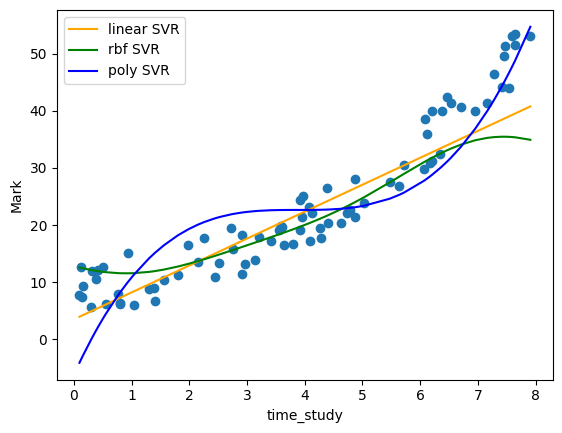

In [ ]:
from matplotlib import pyplot as plt

#### Prediksi model untuk kumpulan data kereta ####
train[ 'linear_svr_pred' ] = regressor_lin.predict(X_train_scaled)
train[ 'rbf_svr_pred' ] = regressor_rbf.predict(X_train_scaled)
train[ 'poly_svr_pred' ] = regressor_poli.predict(X_train_scaled)


#### Visualisasi ####
plt.scatter(train[ 'time_study' ], train[ 'Marks' ])
plt.plot(train[ 'time_study' ], train[ 'linear_svr_pred' ], color = 'orange' , label = 'linear SVR' )
plt.plot(train[ 'time_study' ], train[ 'rbf_svr_pred' ], color = 'green' , label = 'rbf SVR' )
plt.plot(train[ 'time_study' ], train[ 'poly_svr_pred' ], color = 'blue' , label = 'poly SVR' )
plt.legend()
plt.xlabel( 'time_study' )
plt.ylabel( 'Mark' )



Seperti yang disebutkan sebelumnya, SVR memiliki hiperparameter yang dapat disetel; ε , C, dan Kernel. Dengan menyetel hiperparameter ini, kita dapat memperoleh kecocokan model yang lebih baik dengan set data pelatihan.

Di bawah ini, saya mengevaluasi kinerja model SVR linear pada kumpulan data uji menggunakan dua metrik, skor R-kuadrat (R2) dan kesalahan akar rata-rata kuadrat (RMSE) beserta plot nilai target aktual vs. nilai target yang diprediksi.

In [ ]:
import numpy as np
from sklearn import metrics
from sklearn.metrics import r2_score

#### Uji set data - metrik ####
y_test_pred = regressor_lin.predict(X_test_scaled)
r2_score = round(metrics.r2_score(y_test, y_test_pred), 2 )
rmse = round(np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)), 2 )
print( f'r2: {r2_score} ' )
print( f'rmse: {rmse} ' )


r2: 0.83 
rmse: 6.7 


Nilai R2 sebesar 0,83 menunjukkan bahwa sekitar 83% varians nilai siswa dapat dijelaskan oleh rata-rata waktu belajar. Nilai RMSE sebesar 6,7 menunjukkan besarnya rata-rata residual (kesalahan prediksi) antara nilai siswa aktual dan prediksi.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


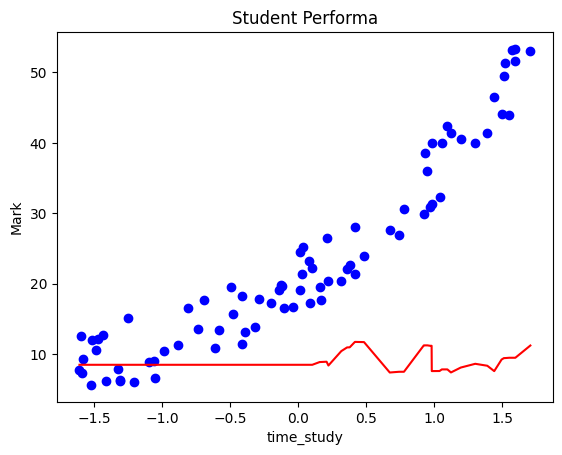

In [ ]:
# Visualising the SVR results
plt.scatter(X_train_scaled, y_train, color = 'blue')
plt.plot(X_train_scaled, regressor.predict(X_train_scaled), color = 'red')
plt.title('Student Performa')
plt.xlabel( 'time_study' )
plt.ylabel( 'Mark' )
plt.show()
plt.show()

## Pertemuan 7 - Unsupervised Learning (Clustering)

### K-MEAN

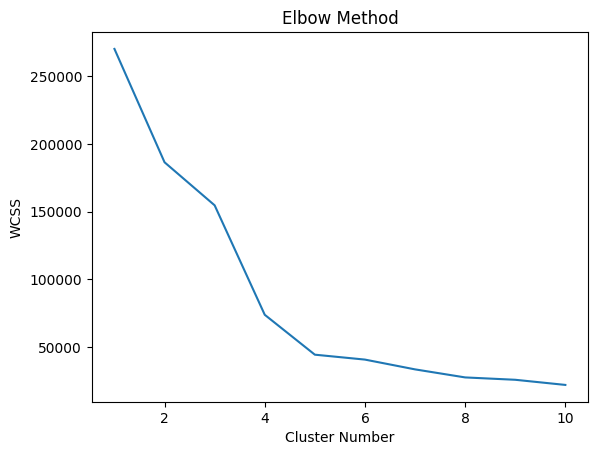

In [ ]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Mengimpor dataset
dataset = pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Customer/Customer.csv')
X = dataset.iloc[:, [3, 4]].values #Yang diambil hanya data di kolom 4 dan 5 maka yang dimasukan adalah index komlom 3 dan 4


# Optimasi K-Means dengan metode elbow untuk menentukan jumlah klaster yangtepat
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)



plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Cluster Number')
plt.ylabel('WCSS')
plt.show()

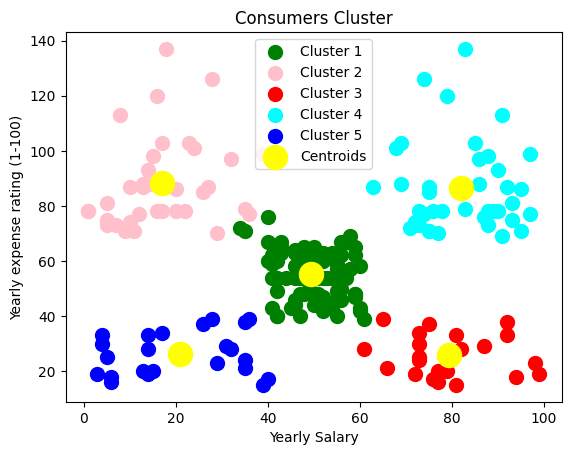

In [ ]:
# Proses K-Means Clustering
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

dataset['tipepengeluaran'] = y_kmeans
# Visualisasi hasil clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'green', label= 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'pink', label= 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'red',label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label= 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'blue',label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s =300, c = 'yellow', label = 'Centroids')
plt.title('Consumers Cluster')
plt.xlabel('Yearly Salary')
plt.ylabel('Yearly expense rating (1-100)')
plt.legend()

In [ ]:
dataset

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp),tipepengeluaran
0,1,Perempuan,23,87,29,2
1,2,Laki,60,4,30,4
2,3,Perempuan,21,73,30,2
3,4,Laki,53,4,33,4
4,5,Laki,18,92,33,2
...,...,...,...,...,...,...
195,196,Laki,28,75,87,3
196,197,Laki,36,10,87,1
197,198,Laki,36,92,87,3
198,199,Perempuan,52,13,88,1


In [ ]:
conditions = [
    (dataset['tipepengeluaran']==0),
    (dataset['tipepengeluaran']==1),
    (dataset['tipepengeluaran']==2),
    (dataset['tipepengeluaran']==3),
    (dataset['tipepengeluaran']==4)]
choices = ['Konsumen Menengah Stabil','Konsumen Boros Berpendapatan rendah','Konsumen Hemat Berpenghasilan Tinggi', 'Konsumen Mewah', 'Konsumen Hemat Berpendapatan Rendah']
dataset['tipepengeluaran'] = np.select(conditions, choices, default='Lainnya')

In [ ]:
dataset

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp),tipepengeluaran
0,1,Perempuan,23,87,29,Konsumen Hemat Berpenghasilan Tinggi
1,2,Laki,60,4,30,Konsumen Hemat Berpendapatan Rendah
2,3,Perempuan,21,73,30,Konsumen Hemat Berpenghasilan Tinggi
3,4,Laki,53,4,33,Konsumen Hemat Berpendapatan Rendah
4,5,Laki,18,92,33,Konsumen Hemat Berpenghasilan Tinggi
...,...,...,...,...,...,...
195,196,Laki,28,75,87,Konsumen Mewah
196,197,Laki,36,10,87,Konsumen Boros Berpendapatan rendah
197,198,Laki,36,92,87,Konsumen Mewah
198,199,Perempuan,52,13,88,Konsumen Boros Berpendapatan rendah


In [ ]:
dataset.to_csv('clustered_customer_data.csv', index=False)

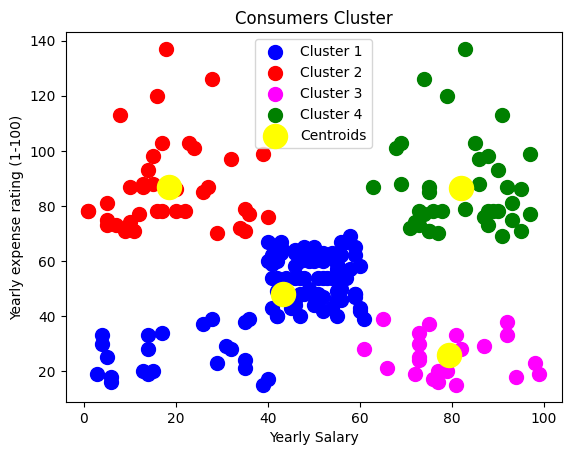

In [ ]:
# Proses K-Means Clustering
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)
# Visualisasi hasil clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'blue', label= 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'red', label= 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'magenta',label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'green',label = 'Cluster 4')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s =300, c = 'yellow', label = 'Centroids')
plt.title('Consumers Cluster')
plt.xlabel('Yearly Salary')
plt.ylabel('Yearly expense rating (1-100)')
plt.legend()

In [ ]:
#Metode Silhouette
from sklearn.metrics import silhouette_score

silhouette_scores = []
number_of_cluster = range(2,21)

for i in number_of_cluster:
  kmeans = KMeans(n_clusters = i)
  kmeans.fit(X)

  labels = kmeans.labels_
  silhouette_scores.append(silhouette_score(X, labels, metric = 'euclidean'))

Text(0, 0.5, 'Silhoutte Score')

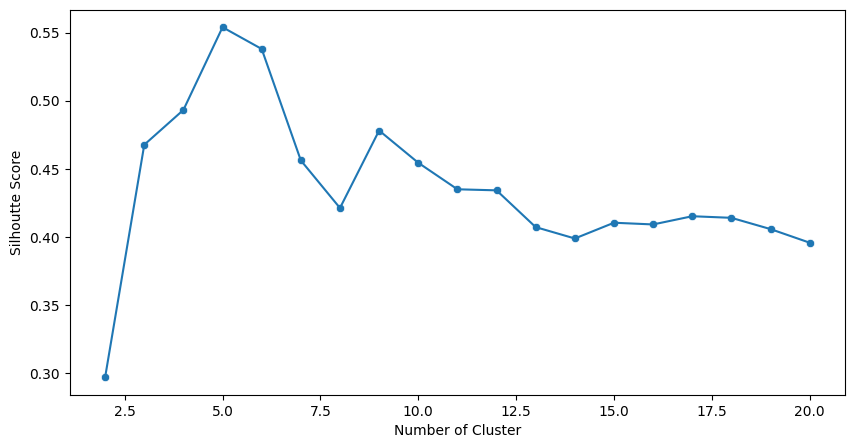

In [ ]:
#Visualisasi grafik silhouette

plt.figure(figsize=(10,5))
sns.lineplot(
    x = range(2,21),
    y = silhouette_scores
)
sns.scatterplot(
    x=range(2,21),
    y=silhouette_scores
)
plt.xticks = range(2,21)
plt.xlabel('Number of Cluster')
plt.ylabel('Silhoutte Score')

Penggunaan Silhouette Score dan Within-Cluster Sum of Squares (WCSS) memiliki hasil yang sama dengan klaster yang paling baik adalah 5

### Hiracial_Clustering

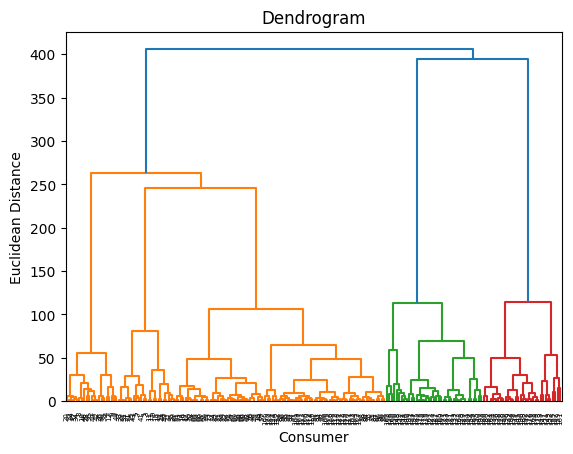

In [ ]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Mengimpor dataset
dataset = pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Customer/Customer.csv')
X = dataset.iloc[:, [3, 4]].values #Data yang diambil kolom ke 4 dan ke 5

# Menggunakan dendrogram untuk menentukan angka cluster yang tepat
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Consumer')
plt.ylabel('Euclidean Distance')
plt.show()

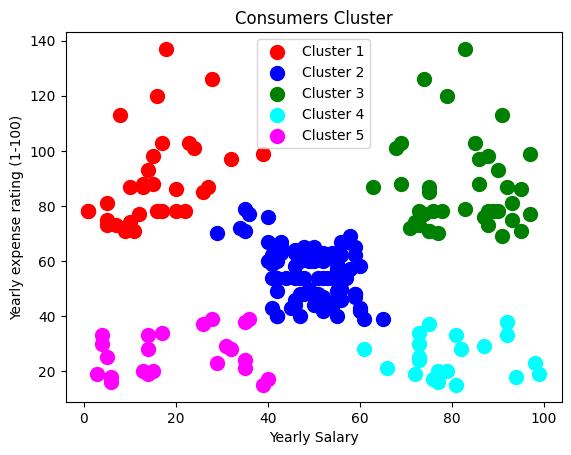

In [ ]:
# Menjalankan Hierarchical Clustering ke dataset
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=5, linkage='ward', metric='euclidean')
y_hc = hc.fit_predict(X)

dataset['tipepengeluaran'] = y_hc
# Visualisasi hasil clusters
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.title('Consumers Cluster')
plt.xlabel('Yearly Salary')
plt.ylabel('Yearly expense rating (1-100)')
plt.legend()
plt.show()

In [ ]:
dataset

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp),tipepengeluaran
0,1,Perempuan,23,87,29,3
1,2,Laki,60,4,30,4
2,3,Perempuan,21,73,30,3
3,4,Laki,53,4,33,4
4,5,Laki,18,92,33,3
...,...,...,...,...,...,...
195,196,Laki,28,75,87,2
196,197,Laki,36,10,87,0
197,198,Laki,36,92,87,2
198,199,Perempuan,52,13,88,0


In [ ]:
#Memberikan Nilai keterangan pada  tipe pengeluaran

conditions = [
    (dataset['tipepengeluaran']==0),
    (dataset['tipepengeluaran']==1),
    (dataset['tipepengeluaran']==2),
    (dataset['tipepengeluaran']==3),
    (dataset['tipepengeluaran']==4) ]
choices = ['Konsumen Menengah Stabil','Konsumen Boros Berpendapatan rendah','Konsumen Hemat Berpenghasilan Tinggi', 'Konsumen Mewah', 'Konsumen Hemat Berpendapatan Rendah']
dataset['tipepengeluaran'] = np.select(conditions, choices, default='Lainnya')

In [ ]:
#Download Dataset Baru

dataset.to_csv('clustered_customer_data.csv', index=False)

### DBSCAN

In [ ]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN

# Mengimpor dataset
dataset = pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Customer/Customer.csv')
X = dataset.iloc[:, [3, 4]].values #Yang diambil hanya data di kolom 4 dan 5 maka yang dimasukan adalah index komlom 3 dan 4

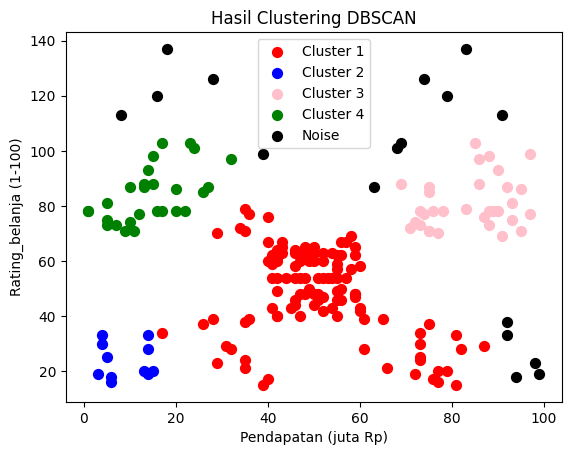

In [ ]:
# Terapkan DBSCAN
dbscan = DBSCAN(eps=10, min_samples=5) # Menyesuaikan parameter eps dan min_samples
y_dbscan = dbscan.fit_predict(X)

# Visualisasi hasil clustering
plt.scatter(X[y_dbscan == 0, 0], X[y_dbscan == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_dbscan == 1, 0], X[y_dbscan == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[y_dbscan == 2, 0], X[y_dbscan == 2, 1], s=50, c='pink', label='Cluster 3')
plt.scatter(X[y_dbscan == 3, 0], X[y_dbscan == 3, 1], s=50, c='green', label='Cluster 4')
plt.scatter(X[y_dbscan == -1, 0], X[y_dbscan == -1, 1], s=50, c='black', label='Noise')  # Titik noise
plt.title("Hasil Clustering DBSCAN")
plt.xlabel("Pendapatan (juta Rp)")
plt.ylabel("Rating_belanja (1-100)")
plt.legend()
plt.show()



In [ ]:
dataset['tipepengeluaran'] = y_dbscan

In [ ]:
dataset

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp),tipepengeluaran
0,1,Perempuan,23,87,29,0
1,2,Laki,60,4,30,1
2,3,Perempuan,21,73,30,0
3,4,Laki,53,4,33,1
4,5,Laki,18,92,33,-1
...,...,...,...,...,...,...
195,196,Laki,28,75,87,2
196,197,Laki,36,10,87,3
197,198,Laki,36,92,87,2
198,199,Perempuan,52,13,88,3


In [ ]:
conditions = [
    (dataset['tipepengeluaran']==-1),
    (dataset['tipepengeluaran']==0),
    (dataset['tipepengeluaran']==1),
    (dataset['tipepengeluaran']==2),
    (dataset['tipepengeluaran']==3),
    ]
choices = ['Noise','Konsumen Menengah Stabil','Konsumen Hemat Berpendapatan Rendah','Konsumen Boros Berpendapatan Rendah', 'Konsumen Mewahf']
dataset['tipepengeluaran'] = np.select(conditions, choices, default='Lainnya')

In [ ]:
dataset

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp),tipepengeluaran
0,1,Perempuan,23,87,29,Konsumen Menengah Stabil
1,2,Laki,60,4,30,Konsumen Hemat Berpendapatan Rendah
2,3,Perempuan,21,73,30,Konsumen Menengah Stabil
3,4,Laki,53,4,33,Konsumen Hemat Berpendapatan Rendah
4,5,Laki,18,92,33,Noise
...,...,...,...,...,...,...
195,196,Laki,28,75,87,Konsumen Boros Berpendapatan Rendah
196,197,Laki,36,10,87,Konsumen Mewahf
197,198,Laki,36,92,87,Konsumen Boros Berpendapatan Rendah
198,199,Perempuan,52,13,88,Konsumen Mewahf


In [ ]:
dataset.to_csv('clustered_customer_data.csv', index=False)

### Tugas

In [ ]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Mengimpor dataset
dataset = pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Customer/CC%20GENERAL.csv')
dataset.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Feature Scaling**

Feature Scaling adalah proses menyesuaikan skala atau rentang nilai dari fitur-fitur dalam dataset agar berada dalam skala yang serupa. Tujuan utamanya adalah untuk meningkatkan performa algoritma pembelajaran mesin, terutama yang bergantung pada perhitungan jarak atau gradien

In [ ]:
# Feature Scaling
from sklearn.preprocessing import MinMaxScaler

# Pilih kolom numerik untuk scaling
numeric_cols = dataset.select_dtypes(include=np.number).columns

# Buat scaler
scaler = MinMaxScaler()

# Scaling data numerik
dataset[numeric_cols] = scaler.fit_transform(dataset[numeric_cols])

# Tampilkan dataset yang sudah di-scaling
dataset.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,0.002148,0.818182,0.001945,0.000000,0.00424,0.000000,0.166667,0.000000,0.083333,0.000000,0.00000,0.005587,0.031720,0.003979,0.001826,0.000000,1.0
1,C10002,0.168169,0.909091,0.000000,0.000000,0.00000,0.136685,0.000000,0.000000,0.000000,0.166667,0.03252,0.000000,0.232053,0.080893,0.014034,0.222222,1.0
2,C10003,0.131026,1.000000,0.015766,0.018968,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.033520,0.248748,0.012264,0.008210,0.000000,1.0
3,C10004,0.087521,0.636364,0.030567,0.036775,0.00000,0.004366,0.083333,0.083333,0.000000,0.055555,0.00813,0.002793,0.248748,0.000000,NaN,0.000000,1.0
4,C10005,0.042940,1.000000,0.000326,0.000393,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.038397,0.013374,0.003204,0.000000,1.0


In [ ]:
# Hitung IQR untuk setiap kolom numerik
Q1 = dataset[numeric_cols].quantile(0.25)
Q3 = dataset[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan atas untuk outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Hapus baris yang mengandung outlier
dataset_no_outliers = dataset[~((dataset[numeric_cols] < lower_bound) | (dataset[numeric_cols] > upper_bound)).any(axis=1)]

# Tampilkan dataset tanpa outlier
dataset_no_outliers.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,0.002148,0.818182,0.001945,0.000000,0.004240,0.000000,0.166667,0.000000,0.083333,0.000000,0.00000,0.005587,0.031720,0.003979,0.001826,0.0,1.0
4,C10005,0.042940,1.000000,0.000326,0.000393,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.038397,0.013374,0.003204,0.0,1.0
7,C10008,0.095764,1.000000,0.008895,0.000000,0.019387,0.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.033520,0.075125,0.013388,0.006963,0.0,1.0
8,C10009,0.053296,1.000000,0.017567,0.016228,0.008889,0.000000,0.333333,0.083333,0.250000,0.000000,0.00000,0.013966,0.232053,0.013570,0.004083,0.0,1.0
14,C10015,0.145605,1.000000,0.000000,0.000000,0.000000,0.007357,0.000000,0.000000,0.000000,0.055555,0.00813,0.000000,0.098497,0.015884,0.012956,0.0,1.0


Text(0, 0.5, 'WCS')

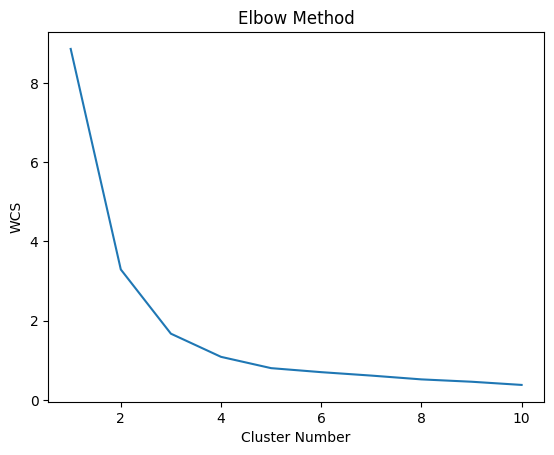

In [ ]:
X = dataset_no_outliers.iloc[:, [1, 5]].values #Data yang diambil kolom ke 4 dan ke 5

# Optimasi K-Means dengan metode elbow untuk menentukan jumlah klaster yangtepat
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)



plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Cluster Number')
plt.ylabel('WCS')

/tmp/ipython-input-75501793.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_no_outliers['tipepengeluaran'] = y_kmeans


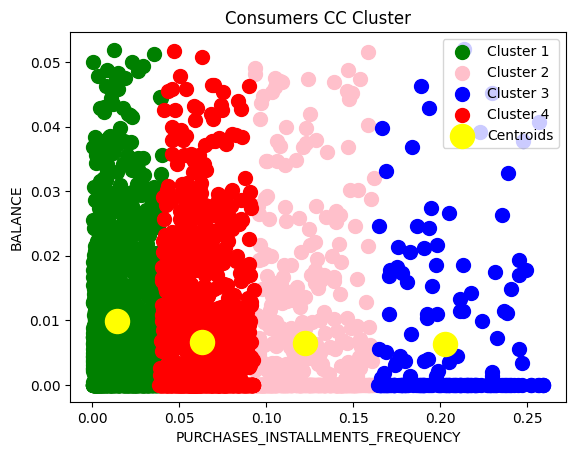

In [ ]:
# Proses K-Means Clustering
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

dataset_no_outliers['tipepengeluaran'] = y_kmeans
# Visualisasi hasil clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'green', label= 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'pink', label= 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'blue', label= 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'red', label= 'Cluster 4')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s =300, c = 'yellow', label = 'Centroids')
plt.title('Consumers CC Cluster')
plt.xlabel('PURCHASES_INSTALLMENTS_FREQUENCY')
plt.ylabel('BALANCE')
plt.legend()

In [ ]:
dataset_no_outliers

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,tipepengeluaran
0,C10001,0.002148,0.818182,0.001945,0.000000,0.004240,0.000000,0.166667,0.000000,0.083333,0.000000,0.00000,0.005587,0.031720,0.003979,0.001826,0.000000,1.0,0
4,C10005,0.042940,1.000000,0.000326,0.000393,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.038397,0.013374,0.003204,0.000000,1.0,3
7,C10008,0.095764,1.000000,0.008895,0.000000,0.019387,0.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.033520,0.075125,0.013388,0.006963,0.000000,1.0,1
8,C10009,0.053296,1.000000,0.017567,0.016228,0.008889,0.000000,0.333333,0.083333,0.250000,0.000000,0.00000,0.013966,0.232053,0.013570,0.004083,0.000000,1.0,3
14,C10015,0.145605,1.000000,0.000000,0.000000,0.000000,0.007357,0.000000,0.000000,0.000000,0.055555,0.00813,0.000000,0.098497,0.015884,0.012956,0.000000,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8738,C18976,0.051530,1.000000,0.027937,0.033610,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.045075,0.011764,0.005910,0.000000,1.0,3
8742,C18980,0.004570,1.000000,0.012348,0.000000,0.026912,0.000000,1.000000,0.000000,0.916667,0.000000,0.00000,0.033520,0.048414,0.010087,0.002290,0.000000,1.0,0
8747,C18986,0.000863,0.909091,0.009003,0.003059,0.014080,0.000000,1.000000,0.166667,0.916667,0.000000,0.00000,0.039106,0.031720,0.009514,0.001195,0.333333,1.0,0
8759,C18998,0.003538,1.000000,0.006016,0.000000,0.013111,0.000000,0.500000,0.000000,0.416667,0.000000,0.00000,0.016760,0.031720,0.004844,0.002187,0.300000,1.0,0


In [ ]:
conditions = [
    (dataset_no_outliers['tipepengeluaran']==0),
    (dataset_no_outliers['tipepengeluaran']==1),
    (dataset_no_outliers['tipepengeluaran']==2),
    (dataset_no_outliers['tipepengeluaran']==3) ]
choices = ['Passive Users', 'Occasional Users','Frequent Users', 'nstallment Enthusiasts']
dataset_no_outliers['tipepengeluaran'] = np.select(conditions, choices)

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

In [ ]:
dataset_no_outliers

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,tipepengeluaran
0,C10001,0.002148,0.818182,0.001945,0.000000,0.004240,0.000000,0.166667,0.000000,0.083333,0.000000,0.00000,0.005587,0.031720,0.003979,0.001826,0.000000,1.0,0
4,C10005,0.042940,1.000000,0.000326,0.000393,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.038397,0.013374,0.003204,0.000000,1.0,3
7,C10008,0.095764,1.000000,0.008895,0.000000,0.019387,0.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.033520,0.075125,0.013388,0.006963,0.000000,1.0,1
8,C10009,0.053296,1.000000,0.017567,0.016228,0.008889,0.000000,0.333333,0.083333,0.250000,0.000000,0.00000,0.013966,0.232053,0.013570,0.004083,0.000000,1.0,3
14,C10015,0.145605,1.000000,0.000000,0.000000,0.000000,0.007357,0.000000,0.000000,0.000000,0.055555,0.00813,0.000000,0.098497,0.015884,0.012956,0.000000,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8738,C18976,0.051530,1.000000,0.027937,0.033610,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.045075,0.011764,0.005910,0.000000,1.0,3
8742,C18980,0.004570,1.000000,0.012348,0.000000,0.026912,0.000000,1.000000,0.000000,0.916667,0.000000,0.00000,0.033520,0.048414,0.010087,0.002290,0.000000,1.0,0
8747,C18986,0.000863,0.909091,0.009003,0.003059,0.014080,0.000000,1.000000,0.166667,0.916667,0.000000,0.00000,0.039106,0.031720,0.009514,0.001195,0.333333,1.0,0
8759,C18998,0.003538,1.000000,0.006016,0.000000,0.013111,0.000000,0.500000,0.000000,0.416667,0.000000,0.00000,0.016760,0.031720,0.004844,0.002187,0.300000,1.0,0


## Pertemuan 9 - Algortima Neural Network  (ANN)

#### Import Library Python

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

#### Memanggil Data Raskin_SMI

In [4]:
df=pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Others/raskin_smi.csv')
df.head()

,No,Jenis_Lantai_Rumah,Jenis_Dinding _Rumah,Sumber_Penerangan_Utama,Pekerjaan,Kepemilikan_Aset,Bahan_Bakar_Memasak,Hasil
0,1,Semen/Papan,Bambu,Listrik,Pekerja Lepas,Tidak,Arang/Kayu,Layak
1,2,Tanah,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak
2,3,Ubin/Keramik/Marmer,Tembok,Listrik,Pedagang,Memiliki,Listrik/Gas,Tidak
3,4,Semen/Papan,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak
4,5,Tanah,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak


#### Persiapan Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   No                       418 non-null    int64 
 1   Jenis_Lantai_Rumah       418 non-null    object
 2   Jenis_Dinding _Rumah     418 non-null    object
 3   Sumber_Penerangan_Utama  418 non-null    object
 4   Pekerjaan                418 non-null    object
 5   Kepemilikan_Aset         418 non-null    object
 6   Bahan_Bakar_Memasak      418 non-null    object
 7   Hasil                    418 non-null    object
dtypes: int64(1), object(7)
memory usage: 26.3+ KB


In [6]:
df.isnull().sum()

,0
No,0
Jenis_Lantai_Rumah,0
Jenis_Dinding _Rumah,0
Sumber_Penerangan_Utama,0
Pekerjaan,0
Kepemilikan_Aset,0
Bahan_Bakar_Memasak,0
Hasil,0


In [7]:
df.isna().sum()

,0
No,0
Jenis_Lantai_Rumah,0
Jenis_Dinding _Rumah,0
Sumber_Penerangan_Utama,0
Pekerjaan,0
Kepemilikan_Aset,0
Bahan_Bakar_Memasak,0
Hasil,0


In [8]:
del df['No']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Jenis_Lantai_Rumah       418 non-null    object
 1   Jenis_Dinding _Rumah     418 non-null    object
 2   Sumber_Penerangan_Utama  418 non-null    object
 3   Pekerjaan                418 non-null    object
 4   Kepemilikan_Aset         418 non-null    object
 5   Bahan_Bakar_Memasak      418 non-null    object
 6   Hasil                    418 non-null    object
dtypes: object(7)
memory usage: 23.0+ KB


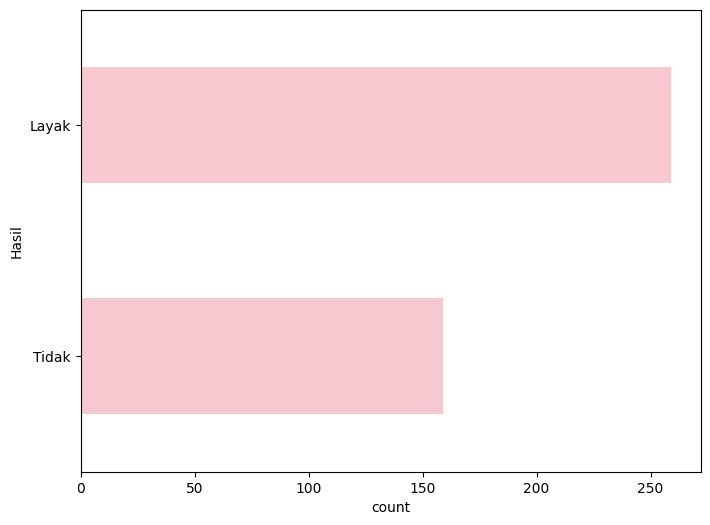

In [10]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    y="Hasil",
    color="pink",
    order=df["Hasil"].value_counts().index, width=0.5
)

In [11]:
df = df.rename(columns={'Jenis_Dinding _Rumah': 'Jenis_Dinding_Rumah'})

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Jenis_Lantai_Rumah       418 non-null    object
 1   Jenis_Dinding_Rumah      418 non-null    object
 2   Sumber_Penerangan_Utama  418 non-null    object
 3   Pekerjaan                418 non-null    object
 4   Kepemilikan_Aset         418 non-null    object
 5   Bahan_Bakar_Memasak      418 non-null    object
 6   Hasil                    418 non-null    object
dtypes: object(7)
memory usage: 23.0+ KB


In [13]:
from sklearn.preprocessing import LabelEncoder
categori_encoder=LabelEncoder()
data=df.copy()

data.Jenis_Lantai_Rumah =categori_encoder.fit_transform(data.Jenis_Lantai_Rumah)
data.Jenis_Dinding_Rumah =categori_encoder.fit_transform(data.Jenis_Dinding_Rumah)
data.Sumber_Penerangan_Utama =categori_encoder.fit_transform(data.Sumber_Penerangan_Utama)
data.Pekerjaan =categori_encoder.fit_transform(data.Pekerjaan)
data.Kepemilikan_Aset =categori_encoder.fit_transform(data.Kepemilikan_Aset)
data.Bahan_Bakar_Memasak=categori_encoder.fit_transform(data.Bahan_Bakar_Memasak)
data.Hasil=categori_encoder.fit_transform(data. Hasil)


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Jenis_Lantai_Rumah       418 non-null    int64
 1   Jenis_Dinding_Rumah      418 non-null    int64
 2   Sumber_Penerangan_Utama  418 non-null    int64
 3   Pekerjaan                418 non-null    int64
 4   Kepemilikan_Aset         418 non-null    int64
 5   Bahan_Bakar_Memasak      418 non-null    int64
 6   Hasil                    418 non-null    int64
dtypes: int64(7)
memory usage: 23.0 KB


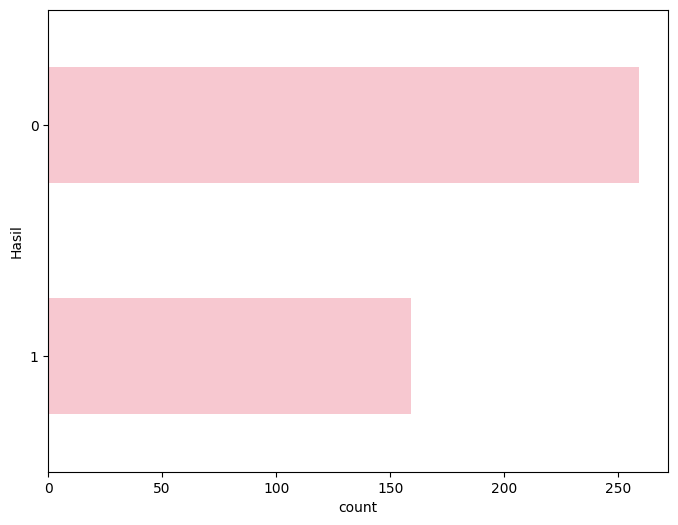

In [15]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=data,
    y="Hasil",
    color="pink",
    order=data["Hasil"].value_counts().index, width=0.5
)

In [16]:
from sklearn.model_selection import train_test_split
X = data.drop(['Hasil'], axis = 1) #Variable yang menampung Data Input
y = data['Hasil'] #Output

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.10)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.15)



print("Banyak data latih setelah dilakukan Train-Validation Split: ", len(X_train))
print("Banyak data uji setelah dilakukan Test Split: ", len(X_test))
print("Banyak data uji setelah dilakukan Validation Split: ", len(X_val))

Banyak data latih setelah dilakukan Train-Validation Split:  319
Banyak data uji setelah dilakukan Test Split:  42
Banyak data uji setelah dilakukan Validation Split:  57


In [17]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64, ), activation='relu',max_iter=1000, epsilon=1e-08)



In [18]:
from sklearn.metrics import accuracy_score

mlp.fit(X_train, y_train)
prediksi_val = mlp.predict(X_val)
acc_val = accuracy_score(y_val, prediksi_val)
print('Akurasi Validasi Training ANN:', acc_val)



Akurasi Validasi Training ANN: 0.9824561403508771


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Akurasi Testing ANN: 0.9285714285714286


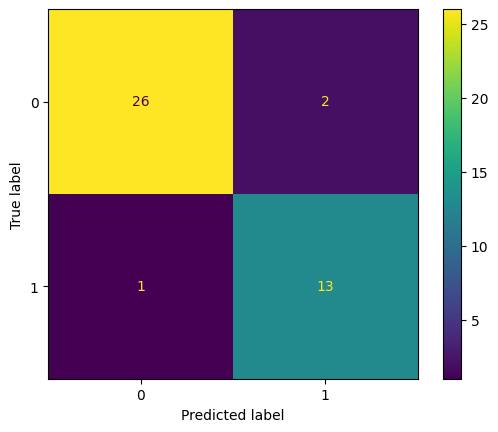

In [19]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

prediksi_test = mlp.predict(X_test)
acc_test = accuracy_score(y_test, prediksi_test)
print('Akurasi Testing ANN:', acc_test)

# Calculate the confusion matrix for the current predictions
cm = confusion_matrix(y_test, prediksi_test, labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=mlp.classes_)

disp.plot()
plt.show()

#### Penggunaan Tensorflow

In [20]:
from keras.utils import to_categorical

y_train = to_categorical(y_train,2)
y_test = to_categorical(y_test,2)
y_val = to_categorical(y_val,2)

In [21]:
from keras.models import Sequential
from keras.layers import Flatten, Dense
import tensorflow as tf
from tensorflow import keras

model = Sequential()
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(2,activation='softmax'))

model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['acc'])

In [22]:
history = model.fit(X_train,y_train,epochs=100,batch_size=5,validation_data=(X_val,y_val))

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.6396 - loss: 0.6784 - val_acc: 0.9298 - val_loss: 0.4856
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9057 - loss: 0.4804 - val_acc: 0.9123 - val_loss: 0.3644
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.8989 - loss: 0.4046 - val_acc: 0.9123 - val_loss: 0.2743
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9279 - loss: 0.2969 - val_acc: 0.9298 - val_loss: 0.2209
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9389 - loss: 0.2840 - val_acc: 0.9298 - val_loss: 0.1941
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9193 - loss: 0.2554 - val_acc: 0.9298 - val_loss: 0.1742
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.9354 - loss: 0.2370 - val_acc: 0.9123 - val_loss: 0.1658
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.9004 - loss: 0.2198 - val_acc: 0.9298 - val_loss: 0.1544
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,736 (6.79 KB)

 Trainable params: 578 (2.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,158 (4.53 KB)

In [24]:
from sklearn.metrics import confusion_matrix

loss, accuracy = model.evaluate(X_test, y_test)
print('Akurasi Testing ANN:', accuracy)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.9315 - loss: 0.0908
Akurasi Testing ANN: 0.9285714030265808


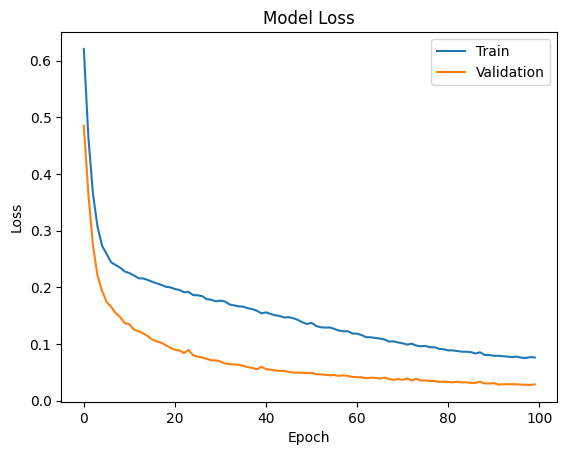

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

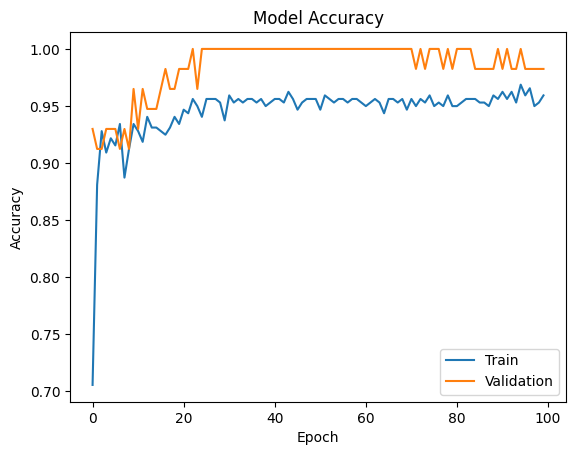

In [26]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

Keterangan:

Lonjakan Akurasi Validasi: Akurasi validasi terlihat memiliki lonjakan tajam pada beberapa epoch tertentu. Hal ini bisa menunjukkan ketidakstabilan pada set validasi atau adanya masalah pada distribusi data.

Fluktuasi Akurasi Pelatihan: Akurasi pelatihan mengalami fluktuasi yang cukup signifikan. Ini mungkin mengindikasikan bahwa model belum konvergen dengan baik atau bahwa learning rate terlalu tinggi.

Stabilitas Akurasi Validasi: Secara umum, akurasi validasi cenderung datar (kecuali lonjakan), yang dapat mengindikasikan bahwa model mengalami overfitting pada data pelatihan tetapi tidak menunjukkan peningkatan pada data validasi.



Kesimpulan Model masih belum Baik

## Pertemuan 11 - Deployment

### Import library

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import Data

In [28]:
dft = pd.read_csv('https://raw.githubusercontent.com/bayhaqy/Datasets/refs/heads/main/Others/raskin_smi.csv')
dft.head()

,No,Jenis_Lantai_Rumah,Jenis_Dinding _Rumah,Sumber_Penerangan_Utama,Pekerjaan,Kepemilikan_Aset,Bahan_Bakar_Memasak,Hasil
0,1,Semen/Papan,Bambu,Listrik,Pekerja Lepas,Tidak,Arang/Kayu,Layak
1,2,Tanah,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak
2,3,Ubin/Keramik/Marmer,Tembok,Listrik,Pedagang,Memiliki,Listrik/Gas,Tidak
3,4,Semen/Papan,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak
4,5,Tanah,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak


### Exploratory Data Analytics

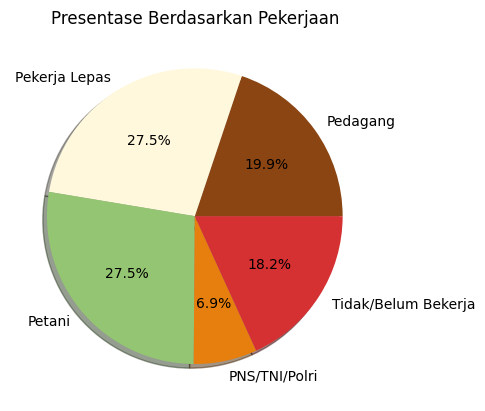

In [29]:
atribut = ['Pedagang', 'Pekerja Lepas', 'Petani', 'PNS/TNI/Polri', 'Tidak/Belum Bekerja']
jumlah = [83, 115, 115, 29, 76]
colors = ('#8B4513', '#FFF8DC', '#93C572', '#E67F0D', '#D53032')
explode = (0, 0, 0, 0, 0)
plt.title('Presentase Berdasarkan Pekerjaan')
plt.pie(
    jumlah,
    labels=atribut,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True
    )
plt.show()

### Data Processing

In [30]:
to_drop = ['No']
dft.drop(to_drop, inplace=True, axis=1)
dft.head()

,Jenis_Lantai_Rumah,Jenis_Dinding _Rumah,Sumber_Penerangan_Utama,Pekerjaan,Kepemilikan_Aset,Bahan_Bakar_Memasak,Hasil
0,Semen/Papan,Bambu,Listrik,Pekerja Lepas,Tidak,Arang/Kayu,Layak
1,Tanah,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak
2,Ubin/Keramik/Marmer,Tembok,Listrik,Pedagang,Memiliki,Listrik/Gas,Tidak
3,Semen/Papan,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak
4,Tanah,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak


In [31]:
dft.isnull()

,Jenis_Lantai_Rumah,Jenis_Dinding _Rumah,Sumber_Penerangan_Utama,Pekerjaan,Kepemilikan_Aset,Bahan_Bakar_Memasak,Hasil
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
413,False,False,False,False,False,False,False
414,False,False,False,False,False,False,False
415,False,False,False,False,False,False,False
416,False,False,False,False,False,False,False


In [32]:
dft.isna().sum()

,0
Jenis_Lantai_Rumah,0
Jenis_Dinding _Rumah,0
Sumber_Penerangan_Utama,0
Pekerjaan,0
Kepemilikan_Aset,0
Bahan_Bakar_Memasak,0
Hasil,0


In [33]:
#Menghapus Semua Missing Data
dft = dft.dropna()
data_column_category = dft.select_dtypes(exclude=[np.number]).columns
dft[data_column_category].head()

,Jenis_Lantai_Rumah,Jenis_Dinding _Rumah,Sumber_Penerangan_Utama,Pekerjaan,Kepemilikan_Aset,Bahan_Bakar_Memasak,Hasil
0,Semen/Papan,Bambu,Listrik,Pekerja Lepas,Tidak,Arang/Kayu,Layak
1,Tanah,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak
2,Ubin/Keramik/Marmer,Tembok,Listrik,Pedagang,Memiliki,Listrik/Gas,Tidak
3,Semen/Papan,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak
4,Tanah,Bambu,Listrik,Tidak/Belum Bekerja,Tidak,Arang/Kayu,Layak


In [34]:
#Data Transform
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()

for i in data_column_category:

    dft[i] = label_encoder.fit_transform(dft[i])

print("Data Baru: ")

dft.head()

Data Baru: 


,Jenis_Lantai_Rumah,Jenis_Dinding _Rumah,Sumber_Penerangan_Utama,Pekerjaan,Kepemilikan_Aset,Bahan_Bakar_Memasak,Hasil
0,0,0,0,1,1,0,0
1,1,0,0,4,1,0,0
2,2,1,0,0,0,1,1
3,0,0,0,4,1,0,0
4,1,0,0,4,1,0,0


### Data Split

In [35]:
X = dft.drop(['Hasil'], axis = 1)
y = dft['Hasil']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state = 0)

### Data Modelling

In [38]:
#Membuat Model Random Forest
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.datasets import make_classification

rf = RandomForestClassifier(max_depth=7, random_state=0)
rf.fit(X, y)

#Membuat Prediksi
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = rf, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))
print(metrics.classification_report(y_test, y_pred))

[[74  3]
 [ 1 48]]
Accuracy: 97.26 %
Standard Deviation: 2.06 %
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        77
           1       0.94      0.98      0.96        49

    accuracy                           0.97       126
   macro avg       0.96      0.97      0.97       126
weighted avg       0.97      0.97      0.97       126



### Export Model

In [36]:
!mkdir deployment -p
!mkdir deployment/templates

In [39]:
import pickle
with open('deployment/Raskin.pkl','wb') as r:
   pickle.dump(rf,r)

### Create Apps with Flask

#### Configure Apps.py

In [61]:
%%writefile deployment/app.py
import numpy as np
from flask import Flask, request, render_template
import pickle

app = Flask(__name__)

model = pickle.load(open('deployment/Raskin.pkl', 'rb'))

@app.route('/')
@app.route('/home')
def home():
    return render_template('index.html')

@app.route('/predict',methods=['POST'])
def predict():

    int_features = [int(X) for X in request.form.values()]

    final_features = [np.array(int_features)]
    prediction= model.predict(final_features)


    output = prediction[0]
    if output == 0 :
        ket="Layak Mendapatkan Bantuan"
    elif output==1:
        ket="Tidak Layak Mendapatkan Bantuan"

    return render_template('index.html', prediction_text=ket)

if __name__ == "__main__":
    app.run(debug=True, port=5000)

Overwriting deployment/app.py


#### Configure Requirements.txt

In [41]:
%%writefile deployment/requirements.txt
flask==3.1.0
numpy
scikit-learn

Writing deployment/requirements.txt


#### Configure html

In [42]:
%%writefile deployment/templates/index.html
<!DOCTYPE html>
<html lang="id">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Penentuan Bantuan Raskin</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 20px;
        }
        .container {
            width: 50%;
            margin: 0 auto;
        }
        h1 {
            text-align: center;
        }
        .form-group {
            margin-bottom: 15px;
        }
        label {
            font-weight: bold;
        }
        select, input {
            width: 100%;
            padding: 8px;
            margin-top: 5px;
        }
        button {
            background-color: #4CAF50;
            color: white;
            padding: 10px 15px;
            border: none;
            cursor: pointer;
            width: 100%;
        }
        button:hover {
            background-color: #45a049;
        }
        .output {
            margin-top: 20px;
            padding: 10px;
            background-color: #f9f9f9;
            border: 1px solid #ccc;
        }
    </style>
</head>
<body>

<div class="container">
    <h1>Penentuan Bantuan Raskin</h1>

    <form action="{{ url_for('predict') }}" method="post" class="flex flex-col">
        <div class="form-group">
            <label for="Jenis_Lantai_Rumah">Pilih Data</label>
            <select name="Jenis_Lantai_Rumah" id="Jenis_Lantai_Rumah">
                <option value="">Choose One</option>
                <option value="0">Semen/Papan</option>
                <option value="1">Tanah</option>
                <option value="2">Ubin/Keramik/Marmer</option>
            </select>

            <h3>Jenis Dinding Rumah</h3>
            <select name="Jenis_Dinding_Rumah" id="Jenis_Dinding_Rumah">
                <option value="">Choose One</option>
                <option value="0">Bambu</option>
                <option value="1">Tembok</option>
            </select>

            <h3>Sumber Penerangan Utama</h3>
            <select name="Sumber_Penerangan_Utama" id="Sumber_Penerangan_Utama">
                <option value="">Choose One</option>
                <option value="0">Listrik</option>
                <option value="1">Non Listrik</option>
            </select>

            <h3>Pekerjaan</h3>
            <select name="Pekerjaan" id="Pekerjaan">
                <option value="">Choose One</option>
                <option value="0">Pedagang</option>
                <option value="1">Pekerja Lepas</option>
                <option value="2">PNS/TNI/Polri</option>
                <option value="3">Petani</option>
                <option value="4">Tidak/Belum Bekerja</option>
            </select>

            <h3>Kepemilikan Aset</h3>
            <select name="Kepemilikan_Aset" id="Kepemilikan_Aset">
                <option value="">Choose One</option>
                <option value="0">Memiliki</option>
                <option value="1">Tidak Memiliki</option>
            </select>

            <h3>Bahan Bakar</h3>
            <select name="Bahan_Bakar" id="Bahan_Bakar">
                <option value="">Choose One</option>
                <option value="0">Arang/Kayu</option>
                <option value="1">Listrik/Gas</option>
            </select>
        </div>

        <button type="submit">Kirim Data</button>
    </form>

    {% if prediction_text %}
    <div class="output">
        <h2>Output:</h2>
        <p><strong>{{ prediction_text }}</strong></p>
    </div>
    {% endif %}
</div>

</body>
</html>

Writing deployment/templates/index.html


#### Check Apps content

In [51]:
!ls deployment

app.py	Raskin.pkl  requirements.txt  templates


#### Install localtunnel untuk run Flask via google colab

In [50]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 1s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦

#### Running Flask dan buat lognya

In [64]:
!python deployment/app.py &>/content/logs.txt &

#### Check log untuk mengetahui IP Public yang akan dimasukkan ke localtunnel

In [65]:
!timeout 30 cat /content/logs.txt

In [66]:
import requests
requests.get('https://api.ipify.org').text

'35.229.58.243'

#### Running localtunnel, Buka linknya dan masukkan IP Public diatas ke Tunnel Passwordnya

In [67]:
!npx localtunnel --port 5000

⠙⠹⠸your url is: https://long-things-enjoy.loca.lt
^C


#### Matikan proses Flask di Ubuntunya

In [68]:
!fuser -k 5000/tcp

5000/tcp:             3386  3435


### Create Apps with Gradio

In [73]:
!mkdir deployment_gradio

#### Configure gradio_app.py

In [127]:
%%writefile deployment_gradio/gradio_app.py
import gradio as gr
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder

# Load the pre-trained model
model = pickle.load(open('deployment/Raskin.pkl', 'rb'))

# Define explicit mappings for label encoding based on index.html and original data processing
jenis_lantai_rumah_map = {"Semen/Papan": 0, "Tanah": 1, "Ubin/Keramik/Marmer": 2}
jenis_dinding_rumah_map = {"Bambu": 0, "Tembok": 1}
sumber_penerangan_utama_map = {"Listrik": 0, "Non Listrik": 1}
pekerjaan_map = {"Pedagang": 0, "Pekerja Lepas": 1, "PNS/TNI/Polri": 2, "Petani": 3, "Tidak/Belum Bekerja": 4}
kepemilikan_aset_map = {"Memiliki": 0, "Tidak Memiliki": 1}
bahan_bakar_memasak_map = {"Arang/Kayu": 0, "Listrik/Gas": 1}

def predict_raskin(
    jenis_lantai_rumah,
    jenis_dinding_rumah,
    sumber_penerangan_utama,
    pekerjaan,
    kepemilikan_aset,
    bahan_bakar_memasak
):
    # Encode input features using the predefined maps
    encoded_jenis_lantai_rumah = jenis_lantai_rumah_map[jenis_lantai_rumah]
    encoded_jenis_dinding_rumah = jenis_dinding_rumah_map[jenis_dinding_rumah]
    encoded_sumber_penerangan_utama = sumber_penerangan_utama_map[sumber_penerangan_utama]
    encoded_pekerjaan = pekerjaan_map[pekerjaan]
    encoded_kepemilikan_aset = kepemilikan_aset_map[kepemilikan_aset]
    encoded_bahan_bakar_memasak = bahan_bakar_memasak_map[bahan_bakar_memasak]

    # Create a NumPy array from the encoded features
    features = np.array([
        encoded_jenis_lantai_rumah,
        encoded_jenis_dinding_rumah,
        encoded_sumber_penerangan_utama,
        encoded_pekerjaan,
        encoded_kepemilikan_aset,
        encoded_bahan_bakar_memasak
    ]).reshape(1, -1)

    # Make prediction
    prediction = model.predict(features)[0]

    # Convert numerical prediction to human-readable string
    if prediction == 0:
        result = "Layak Mendapatkan Bantuan"
    else:
        result = "Tidak Layak Mendapatkan Bantuan"

    return result

# Create Gradio Interface
iface = gr.Interface(
    fn=predict_raskin,
    inputs=[
        gr.Dropdown(list(jenis_lantai_rumah_map.keys()), label="Jenis Lantai Rumah"),
        gr.Dropdown(list(jenis_dinding_rumah_map.keys()), label="Jenis Dinding Rumah"),
        gr.Dropdown(list(sumber_penerangan_utama_map.keys()), label="Sumber Penerangan Utama"),
        gr.Dropdown(list(pekerjaan_map.keys()), label="Pekerjaan"),
        gr.Dropdown(list(kepemilikan_aset_map.keys()), label="Kepemilikan Aset"),
        gr.Dropdown(list(bahan_bakar_memasak_map.keys()), label="Bahan Bakar Memasak")
    ],
    outputs="text",
    title="Prediksi Kelayakan Bantuan Raskin",
    description="Aplikasi untuk memprediksi kelayakan mendapatkan bantuan Raskin berdasarkan fitur-fitur rumah tangga."
)

# Launch the Gradio app
if __name__ == "__main__":
    iface.launch(share=True, debug=True)
    #iface.launch(share=True, debug=True, auth=("admin", "admin"), ssr_mode=False) -- Set auth to login page

Overwriting deployment_gradio/gradio_app.py


#### Configure Requirements.txt

In [124]:
%%writefile deployment_gradio/requirements.txt
flask==3.1.0
numpy
scikit-learn
gradio

Overwriting deployment_gradio/requirements.txt


#### Check Apps content

In [125]:
!ls deployment_gradio

gradio_app.py  requirements.txt


#### Running Gradio dan buat lognya

In [128]:
!python deployment_gradio/gradio_app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://fc4c75797cdf90932b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://fc4c75797cdf90932b.gradio.live
